# Does quitting smoking cause weight gain, and for whom?
### A causal machine learning analysis of NHEFS along the 8-step pipeline

**Research question.** What is the causal effect of quitting smoking (between 1971 and 1982) on weight change over the same period, and does this effect differ between types of smokers?

**Notation (as in the lecture slides).** Treatment $W_i$ = `qsmk` (1 = quit), outcome $Y_i$ = `wt82_71` (kg), covariates $X_i$ = nine confounders measured at baseline (1971). Potential outcomes $Y_i(1), Y_i(0)$. ATE $\tau = E[Y_i(1) - Y_i(0)]$, CATE $\tau(x) = E[Y_i(1) - Y_i(0) \mid X_i = x]$. Nuisances $\hat m(x) \approx E[Y \mid X = x]$ and $\hat e(x) \approx P[W = 1 \mid X = x]$.

**Pipeline** (Causal Forests slides, "Eight Steps, Two Feedback Loops"):

| Step | What happens here | Main output |
|---|---|---|
| 1. Research question and data collection | load data, check missing outcomes | analysis sample |
| 2. Causal structure | DAG, backdoor check | DAG figure |
| 3. Causal estimand | ATE (primary), CATE (secondary) | estimand definition |
| 4. Identifying assumptions | SUTVA, overlap, balance | overlap histogram, love plot |
| 5. Fit the method | nuisances, causal forest, estimator ladder | ATE with CI |
| 6. Evaluate | calibration test, heterogeneity check, RATE | is the heterogeneity real? |
| 7. Robustness | placebo, random cause, semi-synthetic, sensitivity, censoring | robustness scorecard |
| 8. Interpretation | best linear projection, partial dependence, summary | numbers for the story |

Steps 1 to 4 **identify** (settled before any model is fitted), steps 5 to 8 **estimate and interrogate**. The two feedback loops are implemented as explicit checks: a failed calibration test prints a warning that sends you back to Step 5 (revise), a failed placebo check sends you back to Step 4 (re-examine).

**Markers**
- 📝 **Document**: what to copy into the background document
- 🎤 **Slide candidate**: figure worth considering for the presentation (saved as PNG in `figures/`)
- 🔁 **Feedback loop**: automated check that can send you back to an earlier step
- ✅ **Checkpoint**: values you should see if everything ran correctly
- In code comments: `[CONCEPT]` what it is, `[WHY]` why we need it, `📐` formula, `⚠️` pitfall, `🔗` lecture reference

**How to run.** Always use *Restart Kernel* and then *Run All*. Running cells out of order leaves stale variables in memory and the results can be silently wrong. Expect a few minutes of runtime, most of it in Step 7 (many forest refits).

## 0. Setup
Packages: `causallib` (data), `econml` (generalized random forests, the Python counterpart of R's `grf`), `statsmodels`, `scikit-learn`, `networkx`, `matplotlib`.

In [1]:
# If something is missing, install it once from a NOTEBOOK cell (not from the terminal):
# %pip install causallib econml statsmodels networkx
# ⚠️ If pip wants to downgrade numpy or scikit-learn in your base environment, use a fresh
#    environment instead:  conda create -n causal python=3.11  (then install the packages there)

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import networkx as nx
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

from causallib.datasets import load_nhefs
from econml.grf import CausalForest, RegressionForest

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------------ configuration
SEED = 42                    # one seed for everything: every number below is reproducible
N_TREES = 2000               # forests in the main analysis (econml needs a multiple of 4 for inference)
N_TREES_REFUTE = 1000        # lighter forests for the many refits in Step 7
LEAF_GRID = [5, 10, 20, 40]  # candidate min_samples_leaf values for the causal forest (revise loop)
N_FOLDS = 5                  # cross-fitting folds for the parametric nuisance models
N_BOOT = 500                 # bootstrap replicates for the RATE
N_BOOT_DIRECT = 200          # bootstrap replicates for the direct (outcome model) estimator
N_PLACEBO = 20               # placebo-treatment refits (minimum attainable p-value = 1 / 21)
N_RCC = 5                    # random-common-cause refits
N_SEMISYNTH = 5              # semi-synthetic replicates per scenario (use 20+ for a real simulation study)
ALPHA = 0.05
Z_CRIT = stats.norm.ppf(1 - ALPHA / 2)

# Published reference for validation (Step 5)
REF_HR = {"estimate": 3.4, "ci": (2.4, 4.5),
          "source": "Hernán & Robins (2020), Causal Inference: What If, Ch. 12 (IP weighting)"}

rng = np.random.default_rng(SEED)
# Outputs go to the repository root, whether the notebook runs from notebooks/ or from the root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
RESULTS = {}                 # registry of key numbers, exported at the end for the background document

# ------------------------------------------------------------------ plot style
# 🔗 Data Visualization Principles: declutter (no top/right spines, no tick marks, no grid),
#    one accent colour as the only preattentive highlight, direct labels instead of legends,
#    keep the uncertainty and a source line ("expose the lineage").
GREY, LIGHT, DARK = "#9A9A9A", "#D9D9D9", "#2B2B2B"
ACCENT, ACCENT_2, GOLD = "#0F6E56", "#C0502E", "#C9A227"   # teal = our estimate, rust = warning/threshold
SOURCE = "Source: NHEFS (NCHS/CDC), curated by Hernán & Robins; n = 1,566 smokers, 1971 to 1982. Own analysis."

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 11,
    "axes.titlesize": 14, "axes.labelsize": 11, "axes.labelcolor": DARK,
    "xtick.color": DARK, "ytick.color": DARK, "axes.edgecolor": GREY,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.size": 0, "ytick.major.size": 0,
})


def titles(ax, title, subtitle=None):
    """Action title (the takeaway, bold) plus a grey subtitle (what is shown)."""
    ax.set_title(title, loc="left", fontweight="bold", color=DARK, pad=24 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=GREY, fontsize=10, va="bottom")


def save(fig, name, source=SOURCE):
    """Add the source line, save as PNG for the slides, show inline."""
    fig.text(0.01, -0.02, source, fontsize=8, color=GREY, ha="left", va="top")
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


def fmt_ci(est, lo, hi, unit=" kg"):
    return f"{est:.2f}{unit} (95% CI {lo:.2f} to {hi:.2f})"


print("Setup done. Figures are saved to:", FIG_DIR.resolve())

Setup done. Figures are saved to: /home/user/causal-inference-smoking-weight/figures


---
## Step 1. Research question and data collection

### 1.1 Research question
- **Primary (ATE):** By how many kilograms does quitting smoking change weight over roughly 11 years, compared with continuing to smoke?
- **Secondary (CATE):** Is the effect larger for some smokers than for others, for example heavy versus light smokers?

Why it matters: fear of weight gain is a common reason not to quit. A credible number, and knowing whether it differs between smokers, tells a cessation programme whether weight support should be offered to everyone or targeted at specific groups.

### 1.2 Data collection
NHEFS (NHANES I Epidemiologic Follow-up Study, National Center for Health Statistics / CDC): baseline examination 1971 to 1975, follow-up questionnaire 1982. We use the subset of 1,629 cigarette smokers aged 25 to 74 curated by Hernán & Robins (2020), loaded through `causallib`. It is an **observational** study: nobody was assigned to quit, so quitters and continuing smokers may differ systematically (confounding).

We load the data **without** the default feature engineering (`augment=False, onehot=False`). The default returns 18 covariate columns (one-hot dummies plus squared terms, 20 columns with W and Y). We want the nine original confounders and control the encoding ourselves.

In [2]:
# [CONCEPT] Load the FULL cohort, including people whose 1982 weight is missing (restrict=False)
# [WHY]     We must look at who is missing BEFORE dropping them; dropping first hides selection bias.
nhefs = load_nhefs(raw=False, restrict=False, augment=False, onehot=False)
_, descriptions = load_nhefs(raw=True)          # raw=True returns (full data, variable descriptions)

W_COL, Y_COL = "qsmk", "wt82_71"
X_COLS = list(nhefs.X.columns)                  # the nine baseline confounders
CONT_COLS = ["age", "wt71", "smokeintensity", "smokeyrs"]
BIN_COLS = ["sex", "race"]
CAT_COLS = ["education", "exercise", "active"]  # ordered categories stored as integers

df_full = nhefs.X.assign(**{W_COL: nhefs.a, Y_COL: nhefs.y}).reset_index(drop=True)
df_full["censored"] = df_full[Y_COL].isna().astype(int)

# Readable names for tables and figures
LABELS = {
    "age": "Age", "wt71": "Weight 1971", "smokeintensity": "Cigarettes per day",
    "smokeyrs": "Years smoked", "sex": "Female", "race": "Black or other race",
    "education_1": "Education: 8th grade or less", "education_2": "Education: HS dropout",
    "education_3": "Education: high school", "education_4": "Education: college dropout",
    "education_5": "Education: college or more",
    "exercise_0": "Exercise: much", "exercise_1": "Exercise: moderate", "exercise_2": "Exercise: little or none",
    "active_0": "Activity: very active", "active_1": "Activity: moderate", "active_2": "Activity: inactive",
}

data_dictionary = (descriptions.reindex([W_COL, Y_COL] + X_COLS).rename("description").to_frame()
                   .assign(role=["treatment W", "outcome Y"] + ["confounder X"] * len(X_COLS)))
print(f"Full cohort: {len(df_full):,} smokers, {df_full[Y_COL].isna().sum()} with missing 1982 weight")
data_dictionary

Full cohort: 1,629 smokers, 63 with missing 1982 weight


,description,role
Variable name,,
qsmk,QUIT SMOKING BETWEEN 1ST QUESTIONNAIRE AND 198...,treatment W
wt82_71,WEIGHT CHANGE IN KILOGRAMS,outcome Y
active,"IN YOUR USUAL DAY, HOW ACTIVE ARE YOU? IN 1971...",confounder X
age,AGE IN 1971,confounder X
education,AMOUNT OF EDUCATION BY 1971: 1: 8TH GRADE OR L...,confounder X
exercise,"IN RECREATION, HOW MUCH EXERCISE? IN 1971, 0:m...",confounder X
race,0: WHITE 1: BLACK OR OTHER IN 1971,confounder X
sex,0: MALE 1: FEMALE,confounder X
smokeintensity,NUMBER OF CIGARETTES SMOKED PER DAY IN 1971,confounder X


✅ **Checkpoint:** 1,629 smokers, 63 with missing 1982 weight.

### 1.3 Missing outcomes: is the missingness informative?
63 people have no 1982 weight (they are *censored*). If censoring depends on treatment and covariates, analysing only the complete cases can bias the estimate (selection bias, Hernán & Robins Ch. 8 and 12.6). We check (a) censoring rates by treatment, (b) who is censored, (c) whether quitting predicts censoring after adjusting for X.

In [3]:
# (a) Censoring rate by treatment group
cens_by_w = df_full.groupby(W_COL)["censored"].agg(n="size", censored="sum", rate="mean")
print(cens_by_w.round(3), "\n")

# (b) Who is censored? Baseline means of censored (1) vs. observed (0) people
print(df_full.groupby("censored")[CONT_COLS + BIN_COLS].mean().round(2), "\n")

# (c) Logistic model for censoring
# 🔗 Same covariate specification as the propensity model in Step 4 (Hernán & Robins, Ch. 12):
#    squared terms let age, weight, intensity and duration act non-linearly; C() makes categories dummies
PS_SPEC = ("sex + race + age + I(age**2) + C(education) + smokeintensity + I(smokeintensity**2)"
           " + smokeyrs + I(smokeyrs**2) + C(exercise) + C(active) + wt71 + I(wt71**2)")
cens_model = smf.logit(f"censored ~ {W_COL} + {PS_SPEC}", data=df_full).fit(disp=0)
or_w, p_w = np.exp(cens_model.params[W_COL]), cens_model.pvalues[W_COL]
print(f"Adjusted odds ratio of being censored for quitters: {or_w:.2f} (p = {p_w:.3f})")

RESULTS.update({"n_full": len(df_full), "n_censored": int(df_full["censored"].sum()),
                "cens_rate_quit": cens_by_w.loc[1, "rate"], "cens_rate_noquit": cens_by_w.loc[0, "rate"],
                "cens_or_quit": or_w, "cens_p_quit": p_w})

         n  censored   rate
qsmk                       
0     1201        38  0.032
1      428        25  0.058 

            age   wt71  smokeintensity  smokeyrs   sex  race
censored                                                    
0         43.66  70.83           20.53     24.59  0.51  0.13
1         50.27  76.55           21.19     31.90  0.41  0.14 

Adjusted odds ratio of being censored for quitters: 1.68 (p = 0.072)


✅ **Checkpoint:** censoring 5.8% among quitters vs. 3.2% among non-quitters; the censored are older and heavier.

**How to read it.** Quitters are censored almost twice as often, and censoring is related to age and weight. Missingness is therefore plausibly informative. Decision: main analysis on the complete cases (as Hernán & Robins do), plus inverse probability weighting for censoring as a robustness check in Step 7.5.

### 1.4 Analysis sample

Analysis sample: n = 1,566 | quitters: 403 | continuing smokers: 1163
       count  mean   std    min   25%   50%   75%    max
qsmk                                                    
0     1163.0  1.98  7.45 -41.28 -1.81  2.15  6.12  48.54
1      403.0  4.53  8.75 -22.23 -0.17  3.97  9.69  47.51


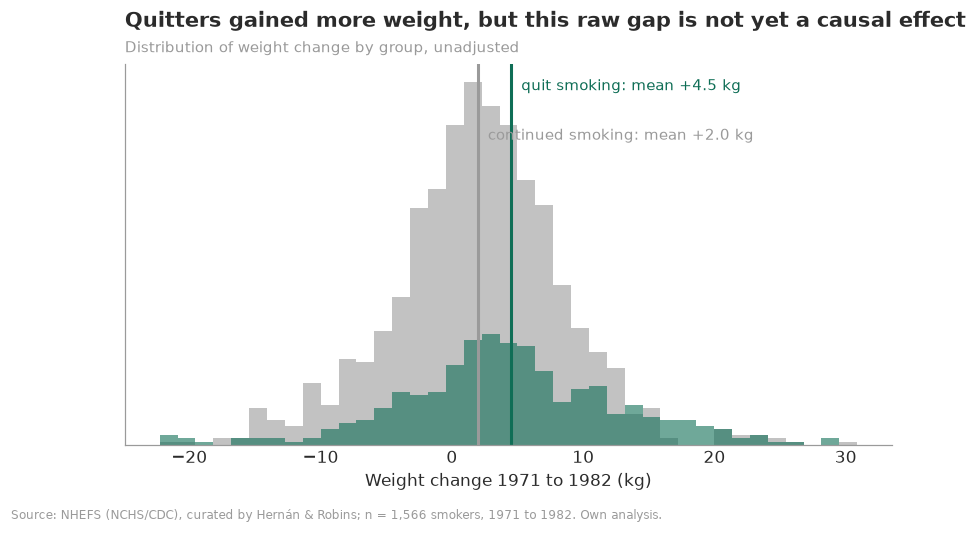

In [4]:
# [CONCEPT] Complete-case analysis sample (the one used by Hernán & Robins)
# [WHY]     All estimators need an observed outcome; Step 7.5 checks what dropping 63 people costs.
df = df_full.loc[df_full["censored"] == 0].drop(columns="censored").reset_index(drop=True)
X = df[X_COLS].to_numpy(dtype=float)    # Shape: (n, 9)
W = df[W_COL].to_numpy(dtype=float)     # Shape: (n,)
Y = df[Y_COL].to_numpy(dtype=float)     # Shape: (n,)
n = len(df)

print(f"Analysis sample: n = {n:,} | quitters: {int(W.sum())} | continuing smokers: {int(n - W.sum())}")
print(df.groupby(W_COL)[Y_COL].describe().round(2))
RESULTS.update({"n": n, "n_quit": int(W.sum()), "n_noquit": int(n - W.sum())})

# Outcome distribution by group (document figure, not a slide)
fig, ax = plt.subplots(figsize=(9, 4.5))
bins_y = np.linspace(np.percentile(Y, 0.5), np.percentile(Y, 99.5), 40)
ax.hist(Y[W == 0], bins=bins_y, color=GREY, alpha=0.6)
ax.hist(Y[W == 1], bins=bins_y, color=ACCENT, alpha=0.6)
ymax = ax.get_ylim()[1]
for grp, col, lab, h in [(0, GREY, "continued smoking", 0.80), (1, ACCENT, "quit smoking", 0.93)]:
    mu = Y[W == grp].mean()
    ax.axvline(mu, color=col, lw=2)
    ax.text(mu, ymax * h, f"  {lab}: mean {mu:+.1f} kg", color=col, fontsize=10)
ax.set_xlabel("Weight change 1971 to 1982 (kg)")
ax.set_yticks([])
titles(ax, "Quitters gained more weight, but this raw gap is not yet a causal effect",
       "Distribution of weight change by group, unadjusted")
save(fig, "fig01_outcome_by_group")

✅ **Checkpoint:** n = 1,566 (403 quitters, 1,163 continuing smokers); mean weight change +4.5 kg vs. +2.0 kg.

> 📝 **Document (Step 1)**
> - Research question (primary and secondary) and why it matters for your audience
> - Data source with citation (NCHS/CDC; Hernán & Robins 2020), observational design, 1971 to 1982
> - Sample flow: 1,629 smokers, 63 without 1982 weight, 1,566 in the analysis
> - Missingness check: censoring 5.8% vs. 3.2%, adjusted odds ratio and p-value, and the decision (complete cases plus IP weighting for censoring in Step 7.5)

---
## Step 2. Causal structure

The DAG encodes what we believe causes what. Our adjustment set X contains nine variables measured in 1971, **before** anyone quit. Each one plausibly affects both the decision to quit and later weight change:

| Confounder | Plausible effect on quitting (W) | Plausible effect on weight change (Y) |
|---|---|---|
| age | older smokers are more health-motivated to quit | weight trajectories change with age |
| sex | quitting rates differ by sex | sex-specific weight dynamics |
| race | social context of smoking and quitting | differences in weight trajectories |
| education | education predicts quitting | education predicts diet and activity |
| cigarettes per day | light smokers quit more easily | nicotine dose affects metabolism and appetite |
| years smoked | long-term smokers find quitting harder | long smoking history, different weight dynamics |
| exercise | healthier lifestyle, more likely to quit | exercise affects weight change |
| daily activity | as above | activity affects weight change |
| weight 1971 | weight concerns may deter quitting | baseline weight affects later gain (regression to the mean) |

**Mediators** such as appetite, metabolic rate or changes in diet after quitting lie on the path W → M → Y. They are part of the effect we want (the *total* effect), so we do **not** adjust for them.

**Unmeasured confounders** U (for example health consciousness or diet in 1971) would open a backdoor path W ← U → Y that X cannot block. We assume they are absent (unconfoundedness) and test in Step 7.4 how strong they would have to be to overturn the result.

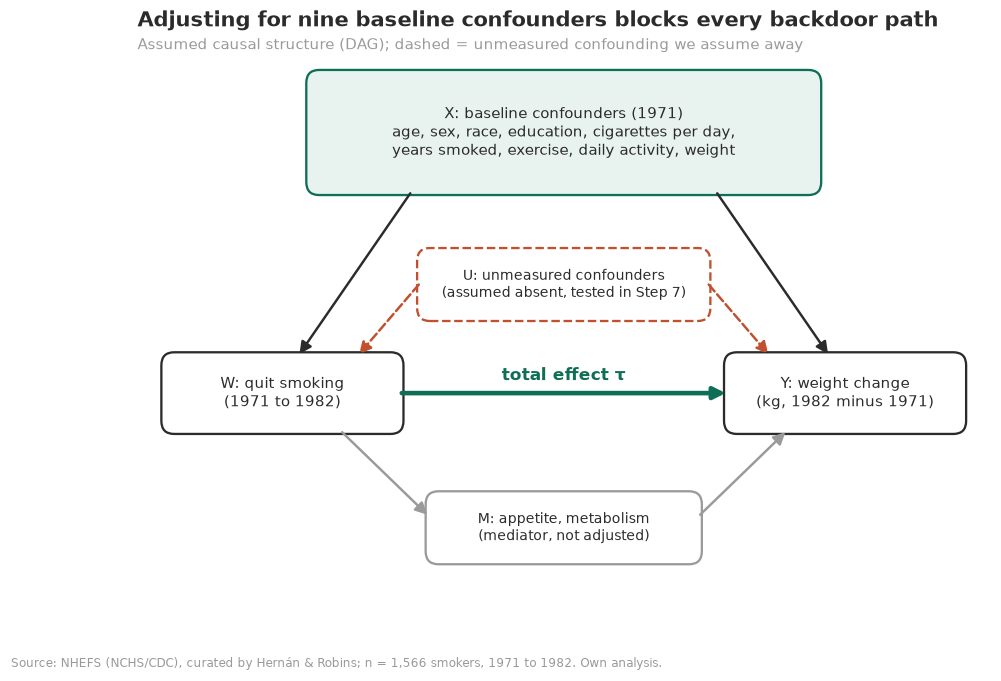

In [5]:
def draw_box(ax, x, y, w, h, text, face="white", edge=DARK, ls="-", fontsize=10):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.02,rounding_size=0.15",
                                facecolor=face, edgecolor=edge, linewidth=1.5, linestyle=ls))
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, color=DARK)


def draw_arrow(ax, start, end, color=DARK, ls="-", lw=1.6):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16, color=color,
                                 linewidth=lw, linestyle=ls, shrinkA=0, shrinkB=0))


fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0.25, 6.1); ax.axis("off")
draw_box(ax, 5.0, 5.3, 6.0, 1.4, "X: baseline confounders (1971)\nage, sex, race, education, cigarettes per day,\n"
         "years smoked, exercise, daily activity, weight", face="#E8F3EF", edge=ACCENT)
draw_box(ax, 1.7, 2.3, 2.8, 0.9, "W: quit smoking\n(1971 to 1982)")
draw_box(ax, 8.3, 2.3, 2.8, 0.9, "Y: weight change\n(kg, 1982 minus 1971)")
draw_box(ax, 5.0, 3.55, 3.4, 0.8, "U: unmeasured confounders\n(assumed absent, tested in Step 7)",
         edge=ACCENT_2, ls="--", fontsize=9)
draw_box(ax, 5.0, 0.75, 3.2, 0.8, "M: appetite, metabolism\n(mediator, not adjusted)", edge=GREY, fontsize=9)

draw_arrow(ax, (3.2, 4.6), (1.9, 2.75))                               # X -> W
draw_arrow(ax, (6.8, 4.6), (8.1, 2.75))                               # X -> Y
draw_arrow(ax, (3.1, 2.3), (6.9, 2.3), color=ACCENT, lw=3)            # W -> Y: the effect we want
ax.text(5.0, 2.45, "total effect τ", color=ACCENT, ha="center", fontweight="bold")
draw_arrow(ax, (2.4, 1.85), (3.4, 0.9), color=GREY)                   # W -> M
draw_arrow(ax, (6.6, 0.9), (7.6, 1.85), color=GREY)                   # M -> Y
draw_arrow(ax, (3.3, 3.55), (2.6, 2.75), color=ACCENT_2, ls="--")     # U -> W
draw_arrow(ax, (6.7, 3.55), (7.4, 2.75), color=ACCENT_2, ls="--")     # U -> Y
titles(ax, "Adjusting for nine baseline confounders blocks every backdoor path",
       "Assumed causal structure (DAG); dashed = unmeasured confounding we assume away")
save(fig, "fig02_dag")

In [6]:
# [CONCEPT] Backdoor criterion (Pearl): a set Z identifies the effect of W on Y if
#           (i) no node in Z is a descendant of W, and
#           (ii) Z d-separates W and Y once all arrows OUT of W are removed.
# [WHY]     The formal version of "adjusting for X is enough". We check it on the assumed DAG,
#           on a DAG with an unmeasured confounder U, and for the mistake of adjusting for a mediator.
# 🔗 Causal Bayesian Networks slides (backdoor games) and the d-separation exercises
d_separated = getattr(nx, "is_d_separator", None) or getattr(nx, "d_separated")  # renamed in networkx 3.3


def satisfies_backdoor(G, w, y, Z):
    Z = set(Z)
    if Z & nx.descendants(G, w):                  # (i) never adjust for something W causes
        return False
    G_back = G.copy()
    G_back.remove_edges_from(list(G.out_edges(w)))  # keep only the non-causal (backdoor) paths
    return d_separated(G_back, {w}, {y}, Z)       # (ii) are they all blocked by Z?


G = nx.DiGraph()
G.add_edges_from([(x, "W") for x in X_COLS] + [(x, "Y") for x in X_COLS])
G.add_edges_from([("W", "Y"), ("W", "M"), ("M", "Y")])
G_with_U = G.copy()
G_with_U.add_edges_from([("U", "W"), ("U", "Y")])

bd_assumed = satisfies_backdoor(G, "W", "Y", X_COLS)
print(f"X satisfies the backdoor criterion in the assumed DAG:         {bd_assumed}")
print(f"X satisfies it if an unmeasured confounder U exists:            {satisfies_backdoor(G_with_U, 'W', 'Y', X_COLS)}")
print(f"X plus the mediator M satisfies it (over-adjustment mistake):   {satisfies_backdoor(G, 'W', 'Y', X_COLS + ['M'])}")
RESULTS["backdoor_assumed_dag"] = bd_assumed

X satisfies the backdoor criterion in the assumed DAG:         True
X satisfies it if an unmeasured confounder U exists:            False
X plus the mediator M satisfies it (over-adjustment mistake):   False


✅ **Checkpoint:** True, False, False. The adjustment set works *only under our DAG*; an unmeasured confounder breaks it, and adding a mediator breaks it too (condition i).

> 📝 **Document (Step 2)**
> - DAG figure and the confounder table above (why each X affects W and Y)
> - Total effect: mediators (appetite, metabolism) are deliberately not adjusted
> - Unconfoundedness is an assumption; pointer to the sensitivity analysis in Step 7.4
> - Output of the backdoor check (True / False / False) and what each line means
>
> 🎤 **Slide candidate:** `fig02_dag.png` for the method slide.

---
## Step 3. Causal estimand

- **Primary: ATE** $\tau = E[Y_i(1) - Y_i(0)]$ among the 1,566 smokers: the average extra weight change if everyone quit versus if nobody quit. We choose the ATE because the policy question concerns smokers in general, not only those who happened to quit.
- **Secondary: CATE** $\tau(x) = E[Y_i(1) - Y_i(0) \mid X_i = x]$: how the effect varies with baseline characteristics. Careful wording: $\tau(x)$ is the average effect for people *like* $x$, not one person's individual effect.
- **Fallback: ATT** $E[Y_i(1) - Y_i(0) \mid W_i = 1]$ if overlap fails in Step 4 ("change the estimand, not the truth").
- Scale: kilograms over the follow-up (about 11 years), total effect.

In [7]:
ESTIMAND = {"primary": "ATE = E[Y(1) - Y(0)]",
            "secondary": "CATE tau(x) = E[Y(1) - Y(0) | X = x]",
            "fallback": "ATT, only if overlap fails",
            "unit": "kg over 1971 to 1982",
            "effect_type": "total effect (mediators not adjusted)"}
RESULTS.update({f"estimand_{k}": v for k, v in ESTIMAND.items()})
pd.Series(ESTIMAND, name="estimand").to_frame()

,estimand
primary,ATE = E[Y(1) - Y(0)]
secondary,CATE tau(x) = E[Y(1) - Y(0) | X = x]
fallback,"ATT, only if overlap fails"
unit,kg over 1971 to 1982
effect_type,total effect (mediators not adjusted)


> 📝 **Document (Step 3):** the three definitions, why the ATE is primary, the CATE wording ("people like x"), unit and total-effect interpretation.

---
## Step 4. Identifying assumptions

On top of i.i.d. data, identification needs three assumptions (Introduction and Treatment Effect Estimation slides):

**4.1 SUTVA** (argued, not tested)
- *Consistency / no hidden versions:* "quitting" is a compound treatment (when, how, relapses). $Y_i(1)$ means weight change under quitting as it happened in this cohort. This is a limitation worth naming.
- *No interference:* one person's quitting does not change another person's weight. Plausible in a population sample; a possible exception are couples who quit together.

**4.2 Positivity / overlap** (testable): every type of smoker must have a real chance of both quitting and not quitting.

**4.3 Unconfoundedness** (not testable): X blocks all backdoor paths (Step 2). The data can only show that the *measured* confounders are balanced after adjustment; unmeasured ones are addressed by the sensitivity analysis in Step 7.4.

Propensity range: 0.051 to 0.777; share outside [0.05, 0.95]: 0.0%
✅ Overlap is adequate: the ATE is identifiable without trimming.


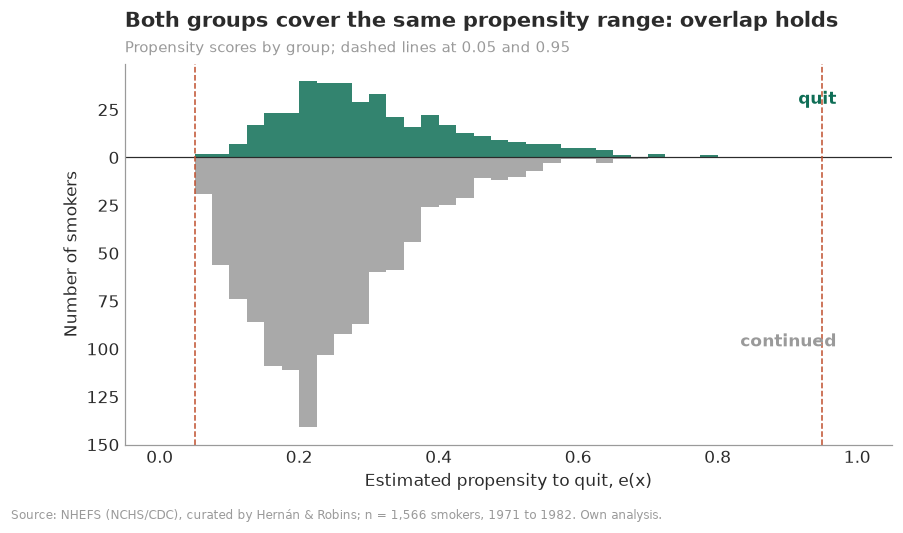

In [8]:
# [CONCEPT] Propensity score e(x) = P(W = 1 | X = x): logistic model, Hernán & Robins specification
# [WHY]     If e(x) is close to 0 or 1 for some people, there is nobody comparable in the other group.
# 🔗 Treatment Effect Estimation slides: "Diagnostic 2: Overlap: Look at the Propensity Histogram"
ps_model = smf.logit(f"{W_COL} ~ {PS_SPEC}", data=df).fit(disp=0)
e_ps = ps_model.predict(df).to_numpy()

share_extreme = np.mean((e_ps < 0.05) | (e_ps > 0.95))
print(f"Propensity range: {e_ps.min():.3f} to {e_ps.max():.3f}; share outside [0.05, 0.95]: {share_extreme:.1%}")

# 🔁 Decision rule: "when overlap fails, change the estimand, not the truth"
OVERLAP_OK = share_extreme < 0.01
print("✅ Overlap is adequate: the ATE is identifiable without trimming." if OVERLAP_OK else
      "⚠️ Overlap problem: switch to the ATT or trim to 0.05 < e(x) < 0.95 and go back to Step 3.")
RESULTS.update({"ps_min": e_ps.min(), "ps_max": e_ps.max(), "ps_share_extreme": share_extreme})

# Mirrored histogram: quitters above the axis, continuing smokers below
fig, ax = plt.subplots(figsize=(9, 4.5))
bins_ps = np.linspace(0, 1, 41)
h1, _ = np.histogram(e_ps[W == 1], bins=bins_ps)
h0, _ = np.histogram(e_ps[W == 0], bins=bins_ps)
ax.bar(bins_ps[:-1], h1, width=np.diff(bins_ps), align="edge", color=ACCENT, alpha=0.85)
ax.bar(bins_ps[:-1], -h0, width=np.diff(bins_ps), align="edge", color=GREY, alpha=0.85)
ax.axhline(0, color=DARK, lw=0.8)
for xv in (0.05, 0.95):
    ax.axvline(xv, color=ACCENT_2, ls="--", lw=1)
ax.text(0.97, h1.max() * 0.7, "quit", color=ACCENT, ha="right", fontweight="bold")
ax.text(0.97, -h0.max() * 0.7, "continued", color=GREY, ha="right", fontweight="bold")
ax.set_xlabel("Estimated propensity to quit, e(x)")
ax.set_ylabel("Number of smokers")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{abs(int(v))}"))
titles(ax, "Both groups cover the same propensity range: overlap holds" if OVERLAP_OK
       else "Some smokers have no comparable counterpart: overlap is violated",
       "Propensity scores by group; dashed lines at 0.05 and 0.95")
save(fig, "fig04a_overlap")

✅ **Checkpoint:** propensities between about 0.05 and 0.78, practically no one outside [0.05, 0.95]. The ATE stays our estimand.

### 4.3 Balance before and after weighting (love plot)

Stabilized weights: mean 0.999 (should be close to 1), range 0.33 to 4.30
                            unadjusted  IP weighted
Age                              0.200        0.004
Cigarettes per day               0.153        0.018
Black or other race              0.125        0.005
Education: college or more       0.117        0.001
Female                           0.113        0.002
Years smoked                     0.112        0.002


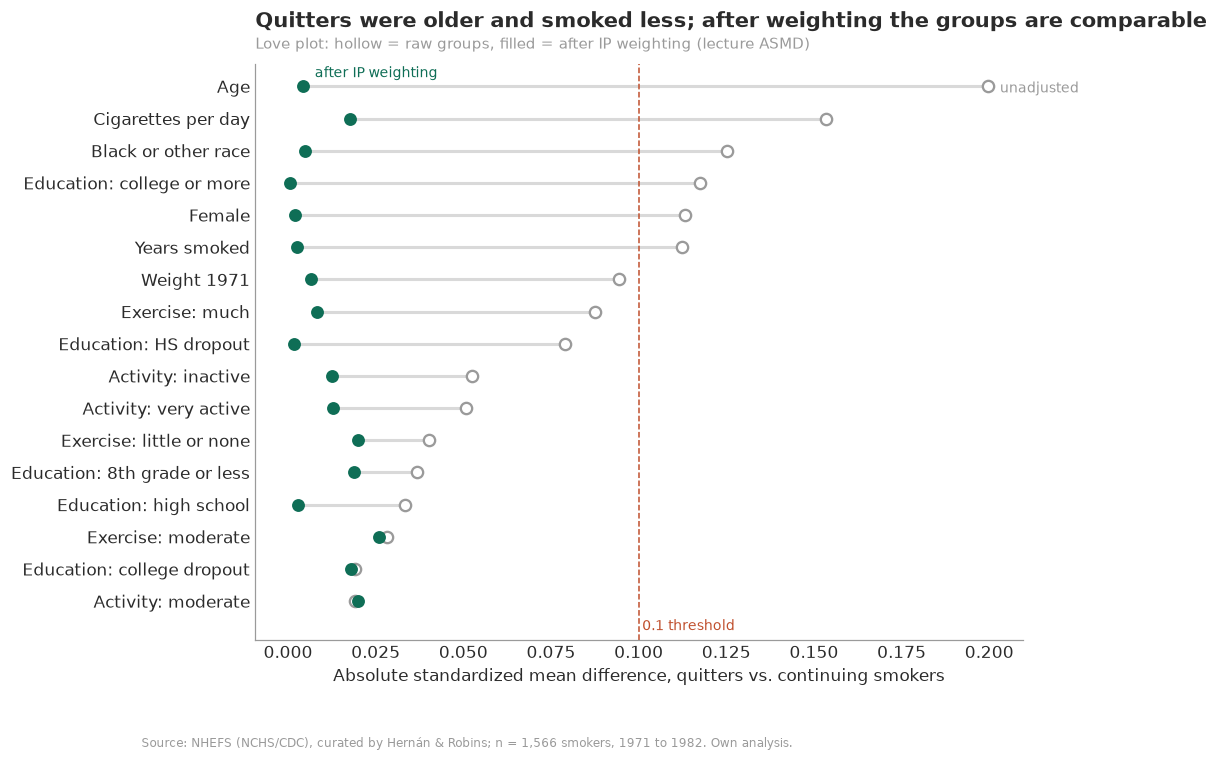

In [9]:
# [CONCEPT] Stabilized inverse probability weights: SW_i = P(W = w_i) / P(W = w_i | X_i)
# [WHY]     Weighting creates a pseudo-population in which X no longer predicts W.
#           If the weights work, the covariates are balanced; the love plot audits exactly this.
# 🔗 Treatment Effect Estimation slides: "Diagnostic 1: Balance: Did the Weights Do Their Job?"
p_quit = W.mean()
sw = np.where(W == 1, p_quit / e_ps, (1 - p_quit) / (1 - e_ps))
print(f"Stabilized weights: mean {sw.mean():.3f} (should be close to 1), range {sw.min():.2f} to {sw.max():.2f}")


def balance_matrix(frame):
    """Continuous and binary covariates as they are, each category level as its own indicator."""
    parts = [frame[CONT_COLS + BIN_COLS].astype(float)]
    parts += [pd.get_dummies(frame[c], prefix=c).astype(float) for c in CAT_COLS]
    return pd.concat(parts, axis=1)


def asmd(z, w, weights):
    """Absolute standardized mean difference, lecture definition: |mean1 - mean0| / sqrt(s1^2 + s0^2)."""
    # ⚠️ Many packages divide by sqrt((s1^2 + s0^2) / 2) instead, which gives values larger by sqrt(2).
    #    We follow the lecture; state which definition you used whenever you quote the 0.1 threshold.
    stats_ = []
    for g in (1, 0):
        m = w == g
        mu = np.average(z[m], weights=weights[m])
        stats_.append((mu, np.average((z[m] - mu) ** 2, weights=weights[m])))
    (mu1, v1), (mu0, v0) = stats_
    return abs(mu1 - mu0) / np.sqrt(v1 + v0)


Bm = balance_matrix(df)
balance = pd.DataFrame({
    "unadjusted": [asmd(Bm[c].to_numpy(), W, np.ones(n)) for c in Bm.columns],
    "IP weighted": [asmd(Bm[c].to_numpy(), W, sw) for c in Bm.columns],
}, index=[LABELS.get(c, c) for c in Bm.columns]).sort_values("unadjusted")
print(balance.sort_values("unadjusted", ascending=False).round(3).head(6))
RESULTS.update({"asmd_max_unadjusted": balance["unadjusted"].max(),
                "asmd_max_weighted": balance["IP weighted"].max()})

# Love plot: one row per covariate, hollow = raw groups, filled = after weighting
fig, ax = plt.subplots(figsize=(9, 6.8))
yy = np.arange(len(balance))
ax.hlines(yy, balance["IP weighted"], balance["unadjusted"], color=LIGHT, lw=2, zorder=1)
ax.scatter(balance["unadjusted"], yy, facecolors="white", edgecolors=GREY, s=55, lw=1.5, zorder=2)
ax.scatter(balance["IP weighted"], yy, color=ACCENT, s=55, zorder=3)
ax.axvline(0.1, color=ACCENT_2, ls="--", lw=1)
ax.text(0.101, -0.9, "0.1 threshold", color=ACCENT_2, fontsize=9)
top = len(balance) - 1
ax.annotate("unadjusted", (balance["unadjusted"].iloc[top], top), xytext=(8, -4),
            textcoords="offset points", color=GREY, fontsize=9)
ax.annotate("after IP weighting", (balance["IP weighted"].iloc[top], top), xytext=(8, 6),
            textcoords="offset points", color=ACCENT, fontsize=9)
ax.set_yticks(yy, labels=balance.index)
ax.set_ylim(-1.2, len(balance) - 0.3)
ax.set_xlabel("Absolute standardized mean difference, quitters vs. continuing smokers")
balanced = balance["IP weighted"].max() < 0.1
quitters, stayers = df[df[W_COL] == 1], df[df[W_COL] == 0]
older = "older" if quitters["age"].mean() > stayers["age"].mean() else "younger"
lighter = "less" if quitters["smokeintensity"].mean() < stayers["smokeintensity"].mean() else "more"
titles(ax, f"Quitters were {older} and smoked {lighter}; after weighting the groups are comparable" if balanced
       else "Some covariates remain imbalanced after weighting",
       "Love plot: hollow = raw groups, filled = after IP weighting (lecture ASMD)")
save(fig, "fig04b_love_plot")

✅ **Checkpoint:** before weighting the largest imbalances are age and cigarettes per day; after weighting every ASMD is far below 0.1.

**How to read it.** The raw groups differ exactly in variables that also drive weight change, which is why the naive comparison is biased. Weighting removes the *measured* imbalance. It says nothing about unmeasured confounders.

> 📝 **Document (Step 4)**
> - SUTVA argument (compound treatment, no interference) as a stated limitation
> - Overlap: propensity range, share outside [0.05, 0.95], decision "ATE, no trimming"
> - Balance: largest ASMD before and after weighting, note on the ASMD definition
> - Unconfoundedness remains an assumption (pointer to Step 7.4)
>
> 🎤 **Slide candidate:** `fig04b_love_plot.png`. The lecture's advice: show the love plot *before* the effect plot, so the audience believes the comparison.

---
## Step 5. Fit the method

Two parts:
1. **The grf workflow** (5.1 to 5.3): nuisances $\hat m, \hat e$, then a causal forest on the residuals, then its doubly robust ATE.
2. **The estimator ladder** (5.4): difference in means, direct estimation, IPW, AIPW. If adjustment matters, the naive estimate moves; if the adjusted estimators agree with each other and with the published value, we trust the number.

### 5.1 Nuisance models
As in the lecture, two honest regression forests with out-of-bag predictions. For comparison we also fit the parametric models (Hernán & Robins specification) with 5-fold cross-fitting. Double machine learning allows any learner; a better nuisance fit only makes the effect estimate less noisy.

In [10]:
# [CONCEPT] grf-style nuisances: two regression forests, predictions made out-of-bag (OOB)
# [WHY]     The OOB prediction for unit i uses only trees grown without i: cross-fitting for free.
#           Without it, Y - m(X) would be overfit and the effect estimate biased.
# 🔗 Causal Forests slides: "Out-of-Bag Predictions: Cross-Fitting for Free"
def fit_m_hat(X_, Y_, n_trees=N_TREES, seed=SEED):
    rf = RegressionForest(n_estimators=n_trees, min_samples_leaf=5, random_state=seed).fit(X_, Y_)
    return rf.oob_predict(X_).ravel()                      # m(x) = E[Y | X = x]


def fit_e_hat(X_, W_, n_trees=N_TREES, seed=SEED, clip=0.01):
    rf = RegressionForest(n_estimators=n_trees, min_samples_leaf=5, random_state=seed).fit(X_, W_)
    # ⚠️ Clip away from 0 and 1: the AIPW score divides by e(1 - e). Not binding in NHEFS.
    return np.clip(rf.oob_predict(X_).ravel(), clip, 1 - clip)   # e(x) = P(W = 1 | X = x)


m_hat = fit_m_hat(X, Y)
e_hat = fit_e_hat(X, W)

# Parametric benchmark, cross-fitted by hand: fit on K-1 folds, predict the held-out fold
OUT_SPEC = PS_SPEC
folds = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
m_par, e_par, mu1_par, mu0_par = (np.zeros(n) for _ in range(4))
for tr, te in folds.split(X, W):
    d_tr, d_te = df.iloc[tr], df.iloc[te]
    e_par[te] = smf.logit(f"{W_COL} ~ {PS_SPEC}", data=d_tr).fit(disp=0).predict(d_te).to_numpy()
    m_par[te] = smf.ols(f"{Y_COL} ~ {OUT_SPEC}", data=d_tr).fit().predict(d_te).to_numpy()
    # arm-specific outcome models mu_w(x) = E[Y | W = w, X = x], needed for the classic AIPW in 5.4
    mu1_par[te] = smf.ols(f"{Y_COL} ~ {OUT_SPEC}", data=d_tr[d_tr[W_COL] == 1]).fit().predict(d_te).to_numpy()
    mu0_par[te] = smf.ols(f"{Y_COL} ~ {OUT_SPEC}", data=d_tr[d_tr[W_COL] == 0]).fit().predict(d_te).to_numpy()


def r2(y, pred):
    return 1 - np.mean((y - pred) ** 2) / np.var(y)


nuisance_table = pd.DataFrame({
    "m(x): out-of-sample R2": [r2(Y, m_hat), r2(Y, m_par)],
    "e(x): AUC": [roc_auc_score(W, e_hat), roc_auc_score(W, e_par)],
    "e(x): Brier score": [brier_score_loss(W, e_hat), brier_score_loss(W, e_par)],
    "e(x): range": [f"{e_hat.min():.2f} to {e_hat.max():.2f}", f"{e_par.min():.2f} to {e_par.max():.2f}"],
}, index=["regression forests (OOB)", "parametric (5-fold cross-fit)"])
RESULTS.update({"nuis_forest_R2_m": r2(Y, m_hat), "nuis_forest_AUC_e": roc_auc_score(W, e_hat),
                "nuis_param_R2_m": r2(Y, m_par), "nuis_param_AUC_e": roc_auc_score(W, e_par)})
nuisance_table.round(3)

,m(x): out-of-sample R2,e(x): AUC,e(x): Brier score,e(x): range
regression forests (OOB),0.074,0.612,0.186,0.12 to 0.47
parametric (5-fold cross-fit),0.085,0.632,0.183,0.05 to 0.80


**How to read it.** Both nuisance fits are weak (out-of-sample $R^2$ below 0.1, AUC around 0.6). Weight change is hard to predict, and quitting is only mildly predictable from X, which is good news for overlap. Weak nuisances do not threaten identification; they make the estimates noisier. The parametric models fit slightly better. We keep the forests inside the causal forest (the lecture workflow) and use the parametric models in the estimator ladder, so the ladder also shows robustness to the nuisance choice.

### 5.2 Causal forest
The main tuning parameter is `min_samples_leaf`: small leaves are more local but noisier. We fit a small grid and choose by the **R-loss** (Nie & Wager), the out-of-bag error of the residual-on-residual model. The calibration test in Step 6 then checks the chosen forest (🔁 revise loop).

In [11]:
# [CONCEPT] Causal forest = forest-localized Robinson regression of (Y - m) on (W - e)
# 📐 tau(x) = sum_i a_i(x) (Y_i - m_i)(W_i - e_i) / sum_i a_i(x) (W_i - e_i)^2
# [WHY]     Working with residuals removes what X explains in both W and Y, so the splits chase
#           differences in the EFFECT, not differences in baseline weight gain.
# 🔗 Causal Forests slides: "Change One Line: Split on Effect Heterogeneity"
def fit_causal_forest(X_, W_, Y_, m_, e_, min_leaf, n_trees=N_TREES, seed=SEED):
    cf_ = CausalForest(n_estimators=n_trees, min_samples_leaf=min_leaf, honest=True,
                       random_state=seed).fit(X_, W_ - e_, Y_ - m_)
    return cf_, cf_.oob_predict(X_).ravel()     # OOB tau(X_i): the trees that predict i never saw i


def dr_scores(W_, Y_, m_, e_, tau_):
    """AIPW (doubly robust) score per unit, as in grf. Its mean is the ATE."""
    # 📐 Gamma_i = tau_i + (W_i - e_i) / (e_i (1 - e_i)) * (Y_i - m_i - (W_i - e_i) tau_i)
    return tau_ + (W_ - e_) / (e_ * (1 - e_)) * (Y_ - m_ - (W_ - e_) * tau_)


def r_loss(W_, Y_, m_, e_, tau_):
    # 📐 R-loss = mean[((Y - m) - (W - e) tau)^2], lower is better (Nie & Wager 2021)
    return np.mean(((Y_ - m_) - (W_ - e_) * tau_) ** 2)


forests = {}
for leaf in LEAF_GRID:
    cf_leaf, tau_leaf = fit_causal_forest(X, W, Y, m_hat, e_hat, leaf)
    forests[leaf] = {"cf": cf_leaf, "tau": tau_leaf, "r_loss": r_loss(W, Y, m_hat, e_hat, tau_leaf)}
    print(f"min_samples_leaf = {leaf:>3}: R-loss = {forests[leaf]['r_loss']:.3f}, "
          f"spread of tau(x): sd = {tau_leaf.std():.2f} kg")

BEST_LEAF = min(forests, key=lambda k: forests[k]["r_loss"])
cf, tau_hat = forests[BEST_LEAF]["cf"], forests[BEST_LEAF]["tau"]
print(f"\nSelected min_samples_leaf = {BEST_LEAF} (lowest R-loss); re-checked by the calibration test in Step 6.")
RESULTS["cf_min_samples_leaf"] = BEST_LEAF

min_samples_leaf =   5: R-loss = 55.420, spread of tau(x): sd = 1.35 kg


min_samples_leaf =  10: R-loss = 55.358, spread of tau(x): sd = 1.03 kg


min_samples_leaf =  20: R-loss = 55.399, spread of tau(x): sd = 0.73 kg


min_samples_leaf =  40: R-loss = 55.459, spread of tau(x): sd = 0.43 kg

Selected min_samples_leaf = 10 (lowest R-loss); re-checked by the calibration test in Step 6.


### 5.3 Doubly robust ATE from the causal forest

Causal forest ATE (AIPW): 3.38 kg (95% CI 2.46 to 4.30)


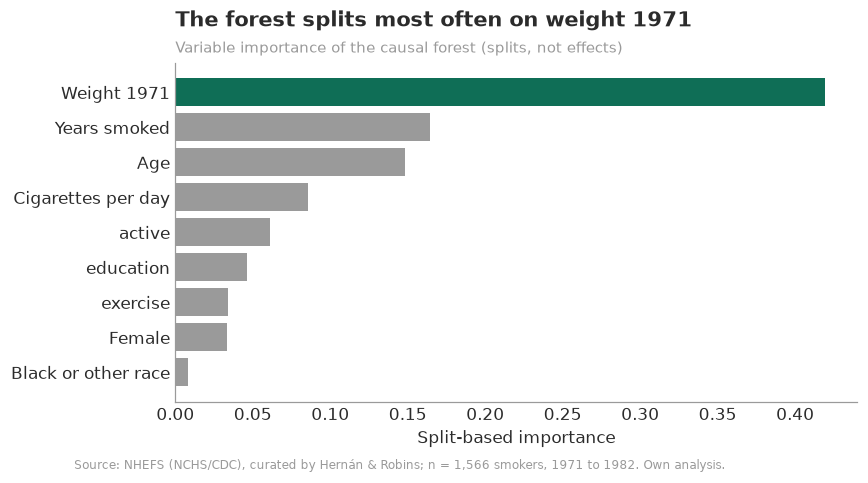

In [12]:
Gamma = dr_scores(W, Y, m_hat, e_hat, tau_hat)          # one AIPW score per person
ate_cf = Gamma.mean()
se_cf = Gamma.std(ddof=1) / np.sqrt(n)
print("Causal forest ATE (AIPW):", fmt_ci(ate_cf, ate_cf - Z_CRIT * se_cf, ate_cf + Z_CRIT * se_cf))

# Which covariates does the forest split on? (grf "variable importance")
# ⚠️ Importance = how often a variable is used for splits, NOT evidence that the effect varies with it.
importance = pd.Series(cf.feature_importances_, index=[LABELS.get(c, c) for c in X_COLS]).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color=GREY)
ax.barh(importance.index[-1], importance.values[-1], color=ACCENT)
ax.set_xlabel("Split-based importance")
titles(ax, f"The forest splits most often on {importance.index[-1].lower()}",
       "Variable importance of the causal forest (splits, not effects)")
save(fig, "fig05a_variable_importance")

### 5.4 The estimator ladder
🔗 Treatment Effect Estimation slides: difference in means (valid only in an RCT) → direct estimation (outcome model, fragile) → IPW (treatment model, fragile differently) → AIPW (both models, doubly robust, the default).

In [13]:
ladder = []

# (1) Difference in means: ignores confounding entirely
naive = Y[W == 1].mean() - Y[W == 0].mean()
se_naive = np.sqrt(Y[W == 1].var(ddof=1) / (W == 1).sum() + Y[W == 0].var(ddof=1) / (W == 0).sum())
ladder.append(("Difference in means (naive)", naive, se_naive))

# (2) Direct estimation = standardization / g-computation (Hernán & Robins, Ch. 13 outcome model)
# [CONCEPT] Fit E[Y | W, X], predict everyone's outcome under do(W = 1) and under do(W = 0), average the difference
# [TIP]     The W x cigarettes interaction lets the effect vary; without it the answer is just the W coefficient
DIRECT_FORMULA = f"{Y_COL} ~ {W_COL} + {W_COL}:smokeintensity + {OUT_SPEC}"


def g_computation(frame):
    fit = smf.ols(DIRECT_FORMULA, data=frame).fit()
    return (fit.predict(frame.assign(**{W_COL: 1})) - fit.predict(frame.assign(**{W_COL: 0}))).mean()


direct = g_computation(df)
boot = [g_computation(df.sample(n, replace=True, random_state=b)) for b in range(N_BOOT_DIRECT)]
ladder.append(("Direct: outcome model", direct, np.std(boot, ddof=1)))

# (3) IPW with stabilized weights, robust (sandwich) SE as in Hernán & Robins, Ch. 12
ipw_fit = smf.wls(f"{Y_COL} ~ {W_COL}", data=df, weights=sw).fit(cov_type="HC0")
ladder.append(("IPW: treatment model", ipw_fit.params[W_COL], ipw_fit.bse[W_COL]))

# (4) AIPW with parametric, cross-fitted nuisances
# 📐 Gamma_i = mu1_i - mu0_i + W_i (Y_i - mu1_i) / e_i - (1 - W_i)(Y_i - mu0_i) / (1 - e_i)
G_par = mu1_par - mu0_par + W * (Y - mu1_par) / e_par - (1 - W) * (Y - mu0_par) / (1 - e_par)
ladder.append(("AIPW: parametric, cross-fit", G_par.mean(), G_par.std(ddof=1) / np.sqrt(n)))

# (5) AIPW with forest nuisances = the causal forest's doubly robust ATE (5.3)
ladder.append(("AIPW: causal forest", ate_cf, se_cf))

ladder = pd.DataFrame(ladder, columns=["estimator", "estimate", "se"]).set_index("estimator")
ladder["ci_low"] = ladder["estimate"] - Z_CRIT * ladder["se"]
ladder["ci_high"] = ladder["estimate"] + Z_CRIT * ladder["se"]
print(ladder.round(2), "\n")
for key, name in zip(["naive", "direct", "ipw", "aipw_param", "aipw_cf"], ladder.index):
    RESULTS[f"ate_{key}"] = ladder.loc[name, "estimate"]
    RESULTS[f"ate_{key}_ci"] = (ladder.loc[name, "ci_low"], ladder.loc[name, "ci_high"])

# ✅ Validation against the published estimate
ipw_est = ladder.loc["IPW: treatment model", "estimate"]
print(f"IPW {ipw_est:.2f} kg vs. Hernán & Robins {REF_HR['estimate']} kg:",
      "✅ reproduced" if abs(ipw_est - REF_HR["estimate"]) < 0.1 else "⚠️ check the propensity specification")

                             estimate    se  ci_low  ci_high
estimator                                                   
Difference in means (naive)      2.54  0.49    1.59     3.50
Direct: outcome model            3.52  0.49    2.57     4.47
IPW: treatment model             3.44  0.53    2.41     4.47
AIPW: parametric, cross-fit      3.26  0.51    2.27     4.26
AIPW: causal forest              3.38  0.47    2.46     4.30 

IPW 3.44 kg vs. Hernán & Robins 3.4 kg: ✅ reproduced


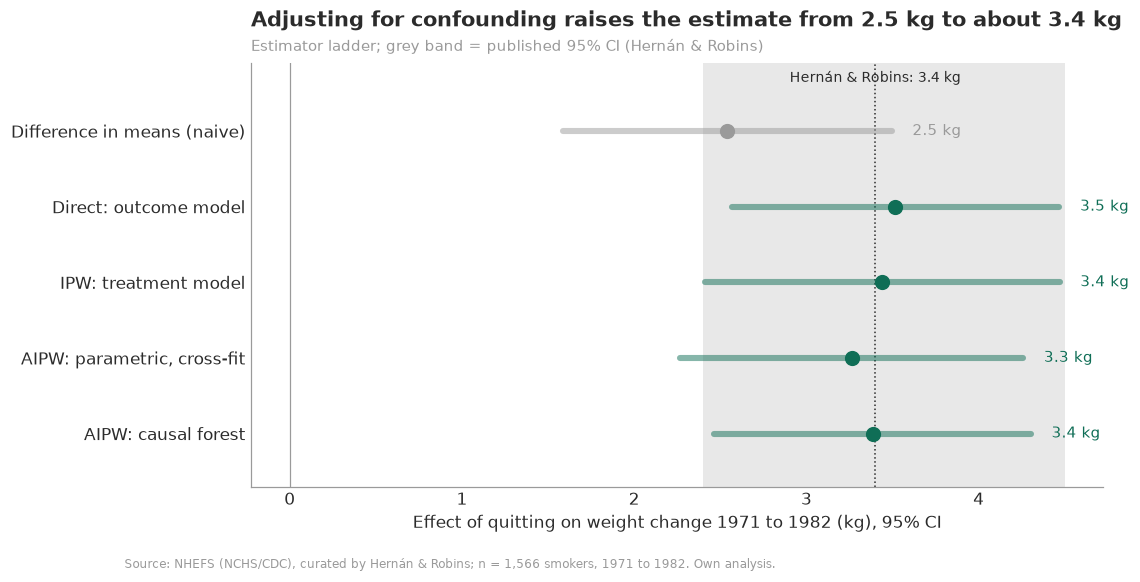

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
yy = np.arange(len(ladder))[::-1]
ax.axvspan(*REF_HR["ci"], color=LIGHT, alpha=0.6, lw=0, zorder=0)
ax.axvline(REF_HR["estimate"], color=DARK, lw=1, ls=":", zorder=1)
ax.text(REF_HR["estimate"], len(ladder) - 0.35, f"Hernán & Robins: {REF_HR['estimate']} kg",
        ha="center", fontsize=9, color=DARK)
for yi, (name, row) in zip(yy, ladder.iterrows()):
    col = GREY if "naive" in name else ACCENT
    ax.plot([row.ci_low, row.ci_high], [yi, yi], color=col, lw=4, alpha=0.5, solid_capstyle="round")
    ax.scatter(row.estimate, yi, color=col, s=80, zorder=3)
    ax.text(row.ci_high + 0.12, yi, f"{row.estimate:.1f} kg", va="center", color=col, fontsize=10)
ax.axvline(0, color=GREY, lw=0.8)
ax.set_yticks(yy, labels=ladder.index)
ax.set_ylim(-0.7, len(ladder) - 0.1)
ax.set_xlabel("Effect of quitting on weight change 1971 to 1982 (kg), 95% CI")
titles(ax, f"Adjusting for confounding raises the estimate from {naive:.1f} kg to about {ate_cf:.1f} kg",
       "Estimator ladder; grey band = published 95% CI (Hernán & Robins)")
save(fig, "fig05b_ate_ladder")

✅ **Checkpoint:** naive 2.54 kg; direct 3.52 kg; IPW 3.44 kg (2.41 to 4.47), matching Hernán & Robins; both AIPW variants around 3.3 to 3.4 kg with CIs of roughly ±0.9 to 1.0 kg.

**How to read it.** The naive estimate is too *low*. Confounding can bias in either direction: quitters were older and heavier at baseline, characteristics that go with smaller weight gain, so the raw comparison hides part of the effect.

> 📝 **Document (Step 5)**
> - Nuisance comparison table and the choice (forests in the causal forest, parametric in the ladder)
> - Causal forest settings: trees, honesty, OOB predictions, selected `min_samples_leaf` with R-loss
> - Estimator ladder table (estimate, SE, CI) and the validation against Hernán & Robins
> - Interpretation of the naive bias direction
>
> 🎤 **Slide candidate:** `fig05b_ate_ladder.png`: the main result slide.

---
## Step 6. Evaluate

The ATE is settled; now we interrogate the CATE. The lecture's warning: *never read heterogeneity off a histogram*. Every prediction $\hat\tau(x)$ carries noise, so predictions vary even if the true effect is identical for everyone. Three honest checks: the calibration test (6.1), predicted vs. confirmed effects by quartile (6.3), and the RATE (6.4).

### 6.1 Calibration test

alpha (mean forest prediction):         1.00  (95% CI 0.72 to 1.27)
beta  (differential forest prediction): 0.54  (95% CI -0.45 to 1.53),  one-sided p(beta > 0) = 0.142


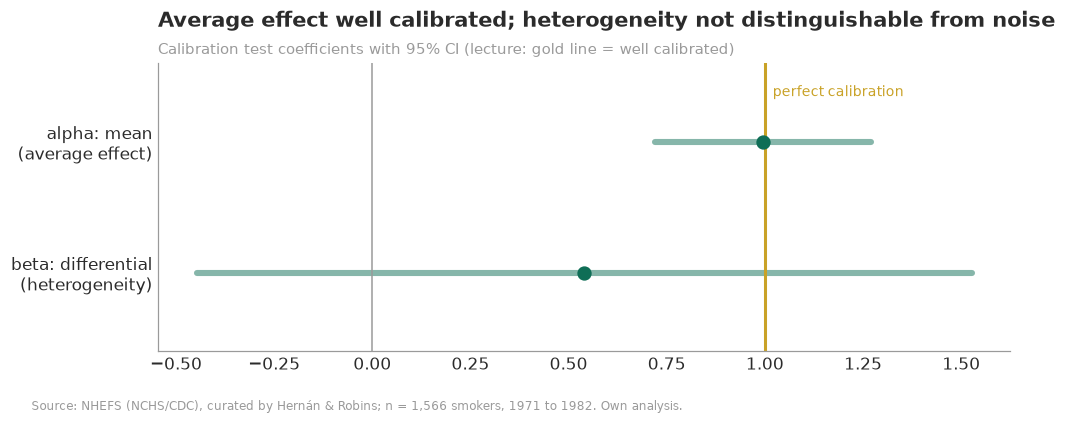

In [15]:
# [CONCEPT] Calibration test (grf test_calibration)
# 📐 Y_i - m_i = alpha * C_i + beta * D_i + eps,  C_i = tau_bar * V_i,  D_i = (tau_i - tau_bar) * V_i,  V_i = W_i - e_i
# [WHY]     alpha ~ 1: the average effect is well calibrated. beta ~ 1: the predicted DIFFERENCES are right.
#           beta significantly > 0: omnibus evidence that heterogeneity exists at all.
# 🔗 Causal Forests slides: "The Calibration Test: Is the Heterogeneity Real?"
def calibration_test(W_, Y_, m_, e_, tau_):
    V = W_ - e_
    tbar = tau_.mean()
    fit = sm.OLS(Y_ - m_, np.column_stack([tbar * V, (tau_ - tbar) * V])).fit(cov_type="HC3")
    (a, b), (se_a, se_b) = fit.params, fit.bse
    return {"alpha": a, "alpha_se": se_a, "beta": b, "beta_se": se_b,
            "p_beta_gt_0": 1 - stats.norm.cdf(b / se_b)}        # one-sided, as in grf


calib = calibration_test(W, Y, m_hat, e_hat, tau_hat)
print(f"alpha (mean forest prediction):         {calib['alpha']:.2f}  (95% CI {calib['alpha'] - Z_CRIT*calib['alpha_se']:.2f} to {calib['alpha'] + Z_CRIT*calib['alpha_se']:.2f})")
print(f"beta  (differential forest prediction): {calib['beta']:.2f}  (95% CI {calib['beta'] - Z_CRIT*calib['beta_se']:.2f} to {calib['beta'] + Z_CRIT*calib['beta_se']:.2f})"
      f",  one-sided p(beta > 0) = {calib['p_beta_gt_0']:.3f}")
HETEROGENEITY_DETECTED = calib["p_beta_gt_0"] < ALPHA
RESULTS.update({f"calib_{k}": v for k, v in calib.items()})
RESULTS["heterogeneity_detected"] = bool(HETEROGENEITY_DETECTED)

fig, ax = plt.subplots(figsize=(10, 3.4))
coefs = [("beta: differential\n(heterogeneity)", calib["beta"], calib["beta_se"]),
         ("alpha: mean\n(average effect)", calib["alpha"], calib["alpha_se"])]
for yi, (lab, est_, se_) in enumerate(coefs):
    ax.plot([est_ - Z_CRIT * se_, est_ + Z_CRIT * se_], [yi, yi], color=ACCENT, lw=4, alpha=0.5, solid_capstyle="round")
    ax.scatter(est_, yi, color=ACCENT, s=70, zorder=3)
ax.axvline(1, color=GOLD, lw=2)
ax.axvline(0, color=GREY, lw=1)
ax.text(1.02, 1.35, "perfect calibration", color=GOLD, fontsize=9)
ax.set_yticks([0, 1], labels=[c[0] for c in coefs])
ax.set_ylim(-0.6, 1.6)
titles(ax, "Average effect well calibrated; " + ("heterogeneity is real" if HETEROGENEITY_DETECTED
       else "heterogeneity not distinguishable from noise"),
       "Calibration test coefficients with 95% CI (lecture: gold line = well calibrated)")
save(fig, "fig06a_calibration")

### 6.2 🔁 Revise loop: does the verdict depend on the leaf size?
A failed calibration test sends you back to Step 5. Instead of trying settings by hand, we evaluate the whole grid from 5.2 and print what to do.

In [16]:
revise = pd.DataFrame({
    leaf: {"R-loss": f["r_loss"],
           **{k: v for k, v in calibration_test(W, Y, m_hat, e_hat, f["tau"]).items()
              if k in ("alpha", "beta", "beta_se", "p_beta_gt_0")}}
    for leaf, f in forests.items()}).T
revise.index.name = "min_samples_leaf"
print(revise.round(3), "\n")

if abs(calib["alpha"] - 1) > Z_CRIT * calib["alpha_se"]:
    print("⚠️ alpha differs from 1: the average effect is miscalibrated. Revisit the nuisances (Step 5.1).")
if calib["beta"] < 0:
    print("⚠️ beta < 0 for the selected forest: its CATE ranking is anti-informative. Try larger leaves (Step 5.2).")
if not (revise["p_beta_gt_0"] < ALPHA).any():
    print("ℹ️ beta is not significantly > 0 for any leaf size: the data cannot confirm heterogeneity.\n"
          "   This is a result, not a bug. Treat every CATE figure below as exploratory.")

                  R-loss  alpha   beta  beta_se  p_beta_gt_0
min_samples_leaf                                            
5                 55.420  0.991  0.434    0.398        0.137
10                55.358  0.995  0.540    0.504        0.142
20                55.399  1.001  0.386    0.712        0.294
40                55.459  0.997 -0.650    1.207        0.705 

ℹ️ beta is not significantly > 0 for any leaf size: the data cannot confirm heterogeneity.
   This is a result, not a bug. Treat every CATE figure below as exploratory.


### 6.3 Predicted vs. confirmed heterogeneity
Group people by their predicted effect (quartiles of $\hat\tau$) and estimate each group's effect with the doubly robust scores $\Gamma_i$. If the forest's differences are real, the confirmed effects rise from Q1 to Q4.

              predicted  confirmed    se
quartile                                
Q1 (lowest)        2.20       3.15  0.83
Q2                 2.96       2.31  0.83
Q3                 3.62       3.30  1.05
Q4 (highest)       4.77       4.78  1.02

Q4 minus Q1 (confirmed): 1.62 kg (95% CI -0.95 to 4.20)


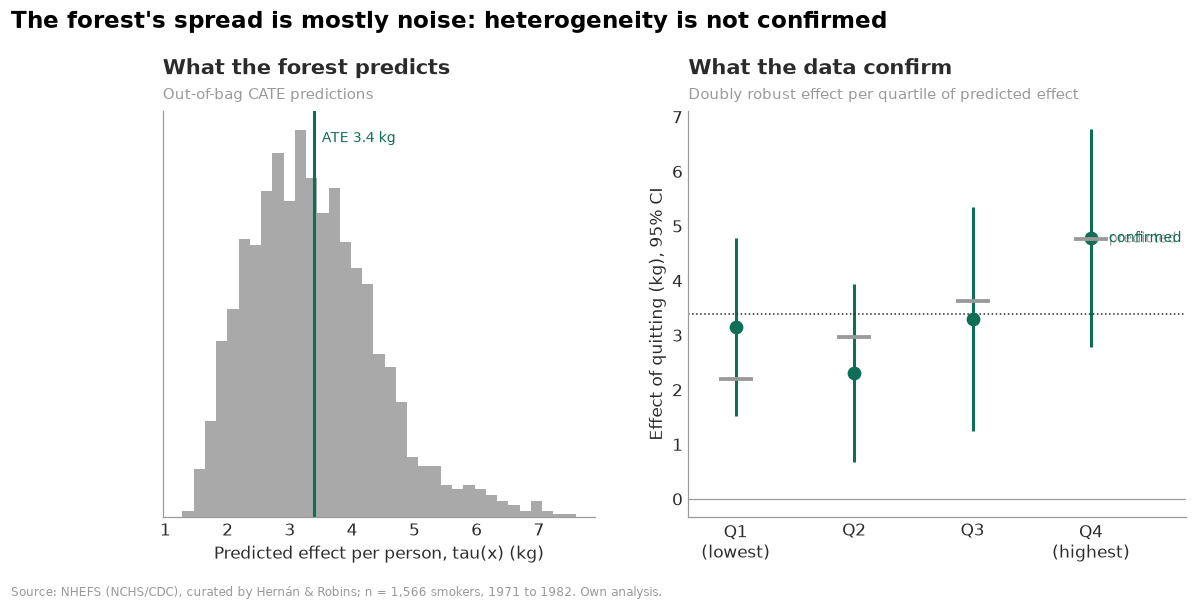

In [17]:
quartile = pd.qcut(tau_hat, 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
q_tab = (pd.DataFrame({"quartile": quartile, "Gamma": Gamma, "tau": tau_hat})
         .groupby("quartile", observed=True)
         .agg(predicted=("tau", "mean"), confirmed=("Gamma", "mean"),
              se=("Gamma", lambda g: g.std(ddof=1) / np.sqrt(len(g)))))
q_diff = q_tab["confirmed"].iloc[-1] - q_tab["confirmed"].iloc[0]
q_diff_se = np.sqrt(q_tab["se"].iloc[-1] ** 2 + q_tab["se"].iloc[0] ** 2)
print(q_tab.round(2))
print(f"\nQ4 minus Q1 (confirmed): {q_diff:.2f} kg (95% CI {q_diff - Z_CRIT*q_diff_se:.2f} to {q_diff + Z_CRIT*q_diff_se:.2f})")
RESULTS.update({"q4_minus_q1": q_diff, "q4_minus_q1_se": q_diff_se})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
ax.hist(tau_hat, bins=35, color=GREY, alpha=0.85)
ax.axvline(ate_cf, color=ACCENT, lw=2)
ax.text(ate_cf, ax.get_ylim()[1] * 0.95, f"  ATE {ate_cf:.1f} kg", color=ACCENT, fontsize=9, va="top")
ax.set_xlabel("Predicted effect per person, tau(x) (kg)")
ax.set_yticks([])
titles(ax, "What the forest predicts", "Out-of-bag CATE predictions")
ax = axes[1]
xq = np.arange(len(q_tab))
ax.errorbar(xq, q_tab["confirmed"], yerr=Z_CRIT * q_tab["se"], fmt="o", color=ACCENT, ms=8, lw=2, capsize=0)
ax.scatter(xq, q_tab["predicted"], marker="_", s=500, color=GREY, lw=2.5, zorder=3)
ax.axhline(ate_cf, color=DARK, ls=":", lw=1)
ax.axhline(0, color=GREY, lw=0.8)
ax.text(xq[-1] + 0.15, q_tab["predicted"].iloc[-1], "predicted", color=GREY, fontsize=9, va="center")
ax.text(xq[-1] + 0.15, q_tab["confirmed"].iloc[-1], "confirmed", color=ACCENT, fontsize=9, va="center")
ax.set_xlim(-0.4, xq[-1] + 0.8)
ax.set_xticks(xq, labels=[lab.replace(" (", "\n(") for lab in q_tab.index])
ax.set_ylabel("Effect of quitting (kg), 95% CI")
titles(ax, "What the data confirm", "Doubly robust effect per quartile of predicted effect")
fig.suptitle("The forest's spread is mostly noise: heterogeneity is not confirmed" if not HETEROGENEITY_DETECTED
             else "Groups predicted to gain more do gain more", x=0.01, ha="left",
             fontweight="bold", fontsize=15, y=1.07)
save(fig, "fig06b_heterogeneity_check")

### 6.4 RATE: can we rank smokers by their effect?
🔗 Causal Forests slides, "Split and Score": learn a prioritization rule on one half of the data, rank the other half with it, and evaluate with that half's doubly robust scores. We compare the causal forest's ranking with a simple rule a counsellor could apply without a model: cigarettes per day.

causal forest        AUTOC =  0.30 kg (95% CI -1.38 to  1.99), QINI = 0.03
cigarettes per day   AUTOC =  0.63 kg (95% CI -1.14 to  2.39), QINI = 0.23


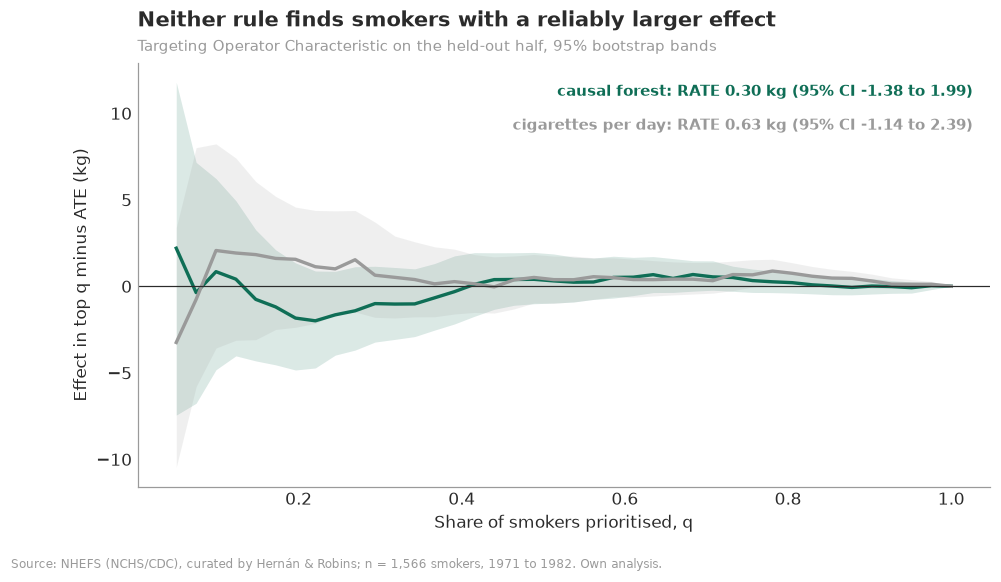

In [18]:
# [CONCEPT] Targeting Operator Characteristic and its area (AUTOC = RATE)
# 📐 TOC(q) = E[Y(1) - Y(0) | top q by S] - ATE;  AUTOC = integral of TOC(q) dq;  QINI = integral of q * TOC(q) dq
# [WHY]     If the same data both rank and evaluate, noise looks like signal. Splitting keeps it honest.
idx_tr, idx_ev = train_test_split(np.arange(n), test_size=0.5, stratify=W, random_state=SEED)

# (a) training half: learn the prioritization rule tau_train(x)
m_tr, e_tr = fit_m_hat(X[idx_tr], Y[idx_tr]), fit_e_hat(X[idx_tr], W[idx_tr])
cf_tr, _ = fit_causal_forest(X[idx_tr], W[idx_tr], Y[idx_tr], m_tr, e_tr, BEST_LEAF)

# (b) evaluation half: doubly robust scores from models fitted on this half only
m_ev, e_ev = fit_m_hat(X[idx_ev], Y[idx_ev]), fit_e_hat(X[idx_ev], W[idx_ev])
_, tau_ev = fit_causal_forest(X[idx_ev], W[idx_ev], Y[idx_ev], m_ev, e_ev, BEST_LEAF)
G_ev = dr_scores(W[idx_ev], Y[idx_ev], m_ev, e_ev, tau_ev)

Q_GRID = np.linspace(0.05, 1.0, 40)   # plotting grid; the top 5% are too few people to show reliably


def toc_curve(S, G):
    """Sort by priority S (descending), cumulative mean of the scores, minus the overall mean."""
    order = np.argsort(-S, kind="stable")
    k = np.arange(1, len(G) + 1)
    return k / len(G), np.cumsum(G[order]) / k - G.mean()


def rate(S, G, n_boot=N_BOOT, seed=SEED):
    r_ = np.random.default_rng(seed)
    q, toc = toc_curve(S, G)
    grid_idx = np.ceil(Q_GRID * len(G)).astype(int) - 1
    boot_autoc, boot_curves = [], []
    for _ in range(n_boot):                       # bootstrap the evaluation half
        i = r_.integers(0, len(G), len(G))
        _, tb = toc_curve(S[i], G[i])
        boot_autoc.append(tb.mean())
        boot_curves.append(tb[grid_idx])
    band = np.percentile(boot_curves, [2.5, 97.5], axis=0)
    return {"q": q, "toc": toc, "autoc": toc.mean(), "se": np.std(boot_autoc, ddof=1),
            "qini": (q * toc).mean(), "band": band, "toc_grid": toc[grid_idx]}


tie_breaker = rng.normal(0, 1e-6, len(idx_ev))   # cigarettes/day has many ties (e.g. 20); break them randomly
priority_rules = {"causal forest": cf_tr.predict(X[idx_ev]).ravel(),
                  "cigarettes per day": X[idx_ev, X_COLS.index("smokeintensity")] + tie_breaker}
rate_res = {name: rate(S, G_ev) for name, S in priority_rules.items()}
for name, rr in rate_res.items():
    print(f"{name:20s} AUTOC = {rr['autoc']:5.2f} kg (95% CI {rr['autoc'] - Z_CRIT*rr['se']:5.2f} to "
          f"{rr['autoc'] + Z_CRIT*rr['se']:5.2f}), QINI = {rr['qini']:.2f}")
    RESULTS[f"rate_autoc_{name.replace(' ', '_')}"] = rr["autoc"]
    RESULTS[f"rate_autoc_se_{name.replace(' ', '_')}"] = rr["se"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, ((name, rr), col) in enumerate(zip(rate_res.items(), [ACCENT, GREY])):
    ax.fill_between(Q_GRID, rr["band"][0], rr["band"][1], color=col, alpha=0.15, lw=0)
    ax.plot(Q_GRID, rr["toc_grid"], color=col, lw=2.2)
    ax.text(0.98, 0.95 - 0.08 * i, f"{name}: RATE {rr['autoc']:.2f} kg (95% CI {rr['autoc'] - Z_CRIT*rr['se']:.2f} to "
            f"{rr['autoc'] + Z_CRIT*rr['se']:.2f})", transform=ax.transAxes, ha="right", va="top",
            color=col, fontsize=10, fontweight="bold")
ax.axhline(0, color=DARK, lw=0.8)
ax.set_xlabel("Share of smokers prioritised, q")
ax.set_ylabel("Effect in top q minus ATE (kg)")
any_sig = any(rr["autoc"] - Z_CRIT * rr["se"] > 0 for rr in rate_res.values())
titles(ax, "Prioritising smokers pays off" if any_sig else "Neither rule finds smokers with a reliably larger effect",
       "Targeting Operator Characteristic on the held-out half, 95% bootstrap bands")
save(fig, "fig06c_rate_toc")

**How to read Step 6.** The calibration test checks *whether* the forest's differences are real, the quartile plot shows *what* the forest predicts against what the data confirm, and the RATE asks whether a ranking would help targeting. If all three are null, the honest conclusion is: *the data cannot distinguish the effect between smokers*. With about 1,600 people and a noisy outcome, that is plausible (Step 7.3 quantifies the power).

> 📝 **Document (Step 6)**
> - Calibration coefficients alpha and beta with CIs and the one-sided p-value; the revise-loop table
> - Quartile table (predicted vs. confirmed) and the Q4 minus Q1 difference
> - RATE (AUTOC) and QINI for both rules, with CIs; note that the split halves the sample (power)
> - Verdict on heterogeneity in one sentence
>
> 🎤 **Slide candidate:** `fig06b_heterogeneity_check.png` if your audience is technical: it shows the lecture's point that a histogram of $\hat\tau$ is not evidence. Keep `fig06a` and `fig06c` for Q&A backup.

---
## Step 7. Robustness

| Check | Idea | Passes if |
|---|---|---|
| 7.1 Placebo treatment | replace W by a random permutation | the "effect" is about 0 and the real one stands out |
| 7.2 Random common cause | add a pure-noise covariate | the estimate does not move |
| 7.3 Semi-synthetic outcome | real X and W, synthetic Y with a **known** effect | the pipeline recovers the truth |
| 7.4 Unmeasured confounding | how strong would U have to be to erase the effect? | stronger than plausible benchmarks |
| 7.5 Missing outcomes | IP weighting for censoring (Step 1.3) | the estimate barely changes |

🔗 Checks 7.1 to 7.3 are the three refutation methods from the lecture (and Assignment Block 10); 7.4 is the causal sensitivity analysis from the introduction slides. 🔁 A failed placebo check sends you back to Step 4.

All refits use the same pipeline as Step 5 with lighter forests (`N_TREES_REFUTE`). To isolate the effect of each manipulation, we compare against a baseline refit with exactly these settings.

In [19]:
def cf_pipeline(X_, W_, Y_, m_=None, e_=None, n_trees=N_TREES_REFUTE, seed=SEED):
    """Nuisances -> causal forest -> AIPW ATE. Reuses m or e when they cannot change."""
    m_ = fit_m_hat(X_, Y_, n_trees, seed) if m_ is None else m_
    e_ = fit_e_hat(X_, W_, n_trees, seed) if e_ is None else e_
    cf_, tau_ = fit_causal_forest(X_, W_, Y_, m_, e_, BEST_LEAF, n_trees, seed)
    G_ = dr_scores(W_, Y_, m_, e_, tau_)
    return {"ate": G_.mean(), "se": G_.std(ddof=1) / np.sqrt(len(G_)), "tau": tau_, "cf": cf_,
            "m": m_, "e": e_, "G": G_}


base = cf_pipeline(X, W, Y)
print(f"Baseline refit ({N_TREES_REFUTE} trees): ATE = {base['ate']:.2f} kg (se {base['se']:.2f})")

Baseline refit (1000 trees): ATE = 3.38 kg (se 0.47)


### 7.1 Placebo treatment

Placebo effects: mean +0.06 kg, sd 0.52 kg; permutation p-value of the real effect = 0.048
✅ Placebo check passed.


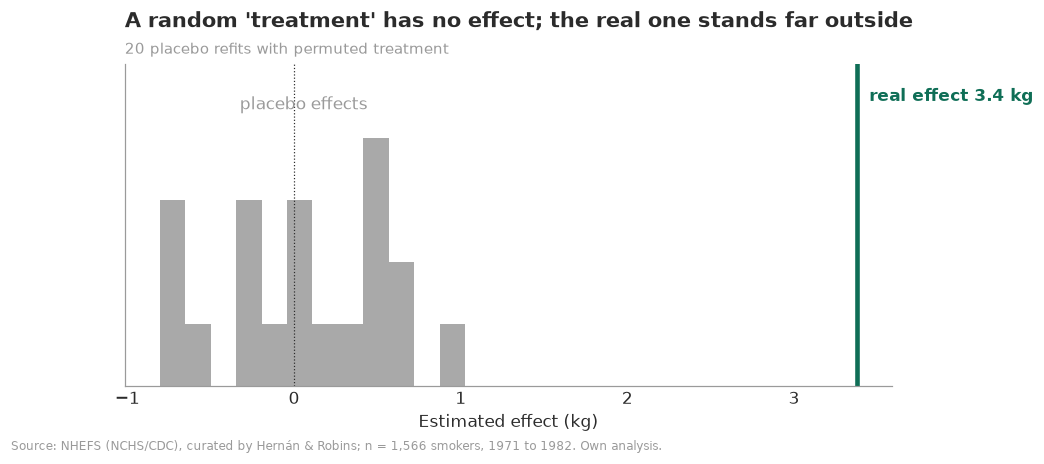

In [20]:
# [WHY] A permuted W cannot cause anything. If the pipeline still finds an "effect", it manufactures
#       effects from the covariates (misspecification or leakage), and no other number can be trusted.
placebo_ates = np.array([
    cf_pipeline(X, W_perm, Y, m_=base["m"])["ate"]          # m(x) = E[Y | X] does not depend on W: reuse it
    for W_perm in (rng.permutation(W) for _ in range(N_PLACEBO))
])
p_placebo = (np.sum(np.abs(placebo_ates) >= abs(base["ate"])) + 1) / (N_PLACEBO + 1)   # smallest possible: 1/(N+1)
t_placebo = placebo_ates.mean() / (placebo_ates.std(ddof=1) / np.sqrt(N_PLACEBO))       # is the placebo mean 0?
PLACEBO_OK = bool((np.abs(placebo_ates) < abs(base["ate"])).all()
                  and abs(t_placebo) < stats.t.ppf(1 - ALPHA / 2, N_PLACEBO - 1))
print(f"Placebo effects: mean {placebo_ates.mean():+.2f} kg, sd {placebo_ates.std(ddof=1):.2f} kg; "
      f"permutation p-value of the real effect = {p_placebo:.3f}")
print("✅ Placebo check passed." if PLACEBO_OK else
      "⚠️ Placebo check failed: re-examine the assumptions in Step 4 (🔁 feedback loop).")
RESULTS.update({"placebo_mean": placebo_ates.mean(), "placebo_sd": placebo_ates.std(ddof=1), "placebo_p": p_placebo})

fig, ax = plt.subplots(figsize=(9, 3.8))
counts, _, _ = ax.hist(placebo_ates, bins=12, color=GREY, alpha=0.85)
ax.set_ylim(0, counts.max() * 1.3)
ax.axvline(base["ate"], color=ACCENT, lw=3)
ax.text(base["ate"], counts.max() * 1.15, f"  real effect {base['ate']:.1f} kg", color=ACCENT, fontweight="bold")
ax.text(placebo_ates.mean(), counts.max() * 1.1, "placebo effects", color=GREY, ha="center", va="bottom")
ax.axvline(0, color=DARK, lw=0.8, ls=":")
ax.set_yticks([])
ax.set_xlabel("Estimated effect (kg)")
titles(ax, "A random 'treatment' has no effect; the real one stands far outside" if PLACEBO_OK
       else "Warning: the pipeline finds effects of a random treatment",
       f"{N_PLACEBO} placebo refits with permuted treatment")
save(fig, "fig07a_placebo")

### 7.2 Random common cause

In [21]:
# [WHY] A covariate that is pure noise is a valid (useless) confounder: adjusting for it must not change the answer.
rcc = []
for r in range(N_RCC):
    X_noise = np.column_stack([X, rng.normal(size=n)])
    res = cf_pipeline(X_noise, W, Y)
    imp = res["cf"].feature_importances_
    rcc.append({"ate": res["ate"], "importance_noise": imp[-1],
                "rank_of_noise (1 = top of 10)": int((imp > imp[-1]).sum() + 1)})
rcc = pd.DataFrame(rcc)
rcc_shift = (rcc["ate"] - base["ate"]).abs().max()
RCC_OK = rcc_shift < 0.5 * base["se"]
print(rcc.round(3))
print(f"\nLargest shift of the ATE: {rcc_shift:.3f} kg (threshold: half a standard error = {0.5 * base['se']:.2f} kg)")
print("✅ Random-common-cause check passed." if RCC_OK else "⚠️ The estimate reacts to noise: check forest stability.")
print("ℹ️ Look at the rank of the noise variable: if pure noise ranks among the real covariates, the forest's\n"
      "   splits are close to arbitrary, one more sign that importance is not evidence of heterogeneity.")
RESULTS.update({"rcc_max_shift": rcc_shift})

     ate  importance_noise  rank_of_noise (1 = top of 10)
0  3.396             0.158                              2
1  3.278             0.168                              2
2  3.316             0.150                              2
3  3.354             0.181                              2
4  3.337             0.153                              2

Largest shift of the ATE: 0.101 kg (threshold: half a standard error = 0.23 kg)
✅ Random-common-cause check passed.
ℹ️ Look at the rank of the noise variable: if pure noise ranks among the real covariates, the forest's
   splits are close to arbitrary, one more sign that importance is not evidence of heterogeneity.


### 7.3 Semi-synthetic outcome: bias and power with a known answer
We keep the real covariates and the real (confounded) treatment, but replace the outcome by $Y^{syn} = f_0(X) + W \cdot \tau^{true}(X) + \varepsilon$, where $f_0$ is fitted on the real continuing smokers and $\varepsilon$ has the real residual noise level. Two scenarios: no heterogeneity ($\tau^{true} = 3.4$ kg for everyone) and strong heterogeneity ($\tau^{true} = 0.2 \times$ cigarettes per day, i.e. 2 kg more per 10 cigarettes).

scenario        no heterogeneity  strong heterogeneity
true_ate                    3.40                  4.11
naive                       2.78                  3.02
estimate                    3.49                  4.03
coverage                    1.00                  1.00
share_beta_sig              0.00                  1.00
blp_slope                  -0.18                  1.93
true_slope                 -0.00                  2.00
share_blp_sig               0.00                  1.00
bias                        0.09                 -0.08 

Bias test (no heterogeneity): t = 0.47 -> ✅ no detectable bias


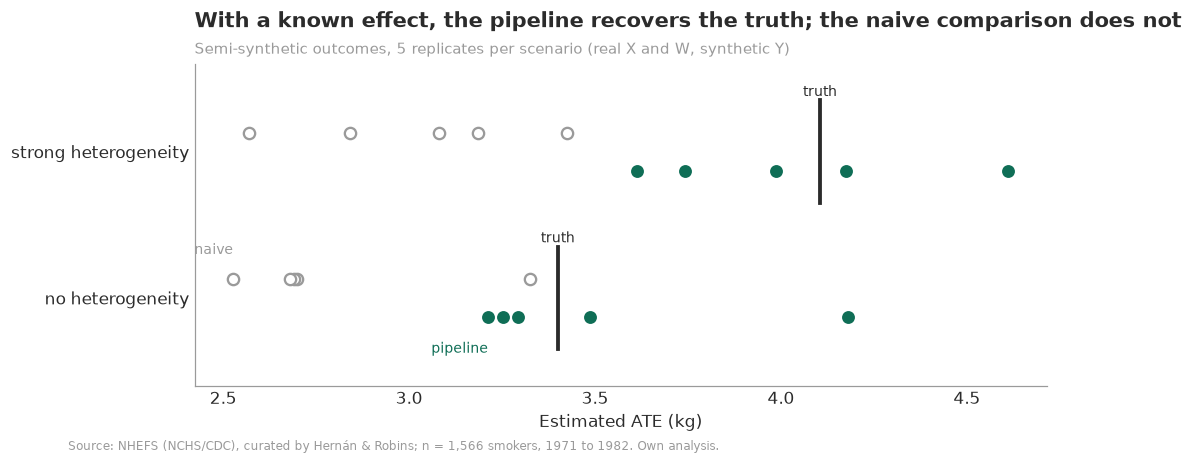

In [22]:
# [CONCEPT] Semi-synthetic validation: the only test in which we KNOW the right answer.
# [WHY]     Scenario 1 checks bias and false alarms (does the pipeline invent heterogeneity?).
#           Scenario 2 checks power (would it find heterogeneity of this size if it existed?).
ctrl_fit = smf.ols(f"{Y_COL} ~ {OUT_SPEC}", data=df[df[W_COL] == 0]).fit()
f0 = ctrl_fit.predict(df).to_numpy()          # realistic baseline: depends on X like the real outcome
sigma = np.sqrt(ctrl_fit.mse_resid)           # realistic noise level
cig = df["smokeintensity"].to_numpy(dtype=float)
scenarios = {"no heterogeneity": np.full(n, 3.4), "strong heterogeneity": 0.2 * cig}

rows = []
for name, tau_true in scenarios.items():
    true_slope = 10 * np.polyfit(cig, tau_true, 1)[0]             # kg per 10 cigarettes
    for r in range(N_SEMISYNTH):
        Y_syn = f0 + W * tau_true + rng.normal(0, sigma, n)
        res = cf_pipeline(X, W, Y_syn, e_=base["e"])               # e(x) does not depend on Y: reuse it
        cal = calibration_test(W, Y_syn, res["m"], res["e"], res["tau"])
        blp_s = sm.OLS(res["G"], sm.add_constant(cig / 10)).fit(cov_type="HC3")
        rows.append({"scenario": name, "true_ate": tau_true.mean(),
                     "naive": Y_syn[W == 1].mean() - Y_syn[W == 0].mean(),
                     "estimate": res["ate"], "covered": abs(res["ate"] - tau_true.mean()) <= Z_CRIT * res["se"],
                     "beta": cal["beta"], "beta_significant": cal["p_beta_gt_0"] < ALPHA,
                     "blp_slope": blp_s.params[1], "blp_significant": blp_s.pvalues[1] < ALPHA,
                     "true_slope": true_slope})
semi = pd.DataFrame(rows)
semi_summary = semi.groupby("scenario", sort=False).agg(
    true_ate=("true_ate", "mean"), naive=("naive", "mean"), estimate=("estimate", "mean"),
    coverage=("covered", "mean"), share_beta_sig=("beta_significant", "mean"),
    blp_slope=("blp_slope", "mean"), true_slope=("true_slope", "mean"), share_blp_sig=("blp_significant", "mean"))
semi_summary["bias"] = semi_summary["estimate"] - semi_summary["true_ate"]

# Is the bias in the homogeneous scenario distinguishable from 0? (t-test over replicates)
s1 = semi[semi["scenario"] == "no heterogeneity"]
t_bias = (s1["estimate"].mean() - s1["true_ate"].mean()) / (s1["estimate"].std(ddof=1) / np.sqrt(len(s1)))
SEMI_OK = abs(t_bias) < stats.t.ppf(1 - ALPHA / 2, len(s1) - 1)
print(semi_summary.round(2).T, "\n")
print(f"Bias test (no heterogeneity): t = {t_bias:.2f} ->", "✅ no detectable bias" if SEMI_OK else "⚠️ systematic bias")
RESULTS.update({"semi_bias_homog": semi_summary.loc["no heterogeneity", "bias"],
                "semi_power_beta_strong": semi_summary.loc["strong heterogeneity", "share_beta_sig"],
                "semi_falsealarm_beta_homog": semi_summary.loc["no heterogeneity", "share_beta_sig"]})

fig, ax = plt.subplots(figsize=(10, 3.8))
for yi, (name, grp) in enumerate(semi.groupby("scenario", sort=False)):
    ax.scatter(grp["naive"], np.full(len(grp), yi + 0.13), facecolors="white", edgecolors=GREY, s=55, lw=1.5)
    ax.scatter(grp["estimate"], np.full(len(grp), yi - 0.13), color=ACCENT, s=55)
    ax.plot([grp["true_ate"].iloc[0]] * 2, [yi - 0.35, yi + 0.35], color=DARK, lw=2.5)
    ax.text(grp["true_ate"].iloc[0], yi + 0.38, "truth", ha="center", fontsize=9, color=DARK)
ax.text(semi["naive"].min(), 0.3, "naive", color=GREY, fontsize=9, ha="right")
ax.text(semi["estimate"].min(), -0.3, "pipeline", color=ACCENT, fontsize=9, ha="right", va="top")
ax.set_yticks(range(len(scenarios)), labels=list(scenarios))
ax.set_ylim(-0.6, len(scenarios) - 0.4)
ax.set_xlabel("Estimated ATE (kg)")
titles(ax, "With a known effect, the pipeline recovers the truth; the naive comparison does not" if SEMI_OK
       else "The pipeline reduces, but does not fully remove, the confounding bias",
       f"Semi-synthetic outcomes, {N_SEMISYNTH} replicates per scenario (real X and W, synthetic Y)")
save(fig, "fig07b_semisynthetic")

**How to read it.** In the homogeneous scenario the naive comparison shows the same downward bias as in the real data, and the pipeline moves back toward the truth. The share of significant calibration tests is the false-alarm rate (scenario 1) and the power (scenario 2). If the forest detects the strong scenario but not the real data, the real heterogeneity, if any, must be weaker than 2 kg per 10 cigarettes.

### 7.4 Sensitivity to unmeasured confounding
Unconfoundedness cannot be tested. Instead we ask how strong an unmeasured confounder U would have to be to erase the effect, and compare that with confounders we *did* measure (benchmarking, as the lecture recommends: "comparisons to known, important causes such as age"). We use the omitted-variable-bias framework of Cinelli & Hazlett (2020) on the linear adjustment estimate, which is transparent and has closed-form bounds.

In [23]:
# [CONCEPT] Omitted variable bias in partial R2 terms (Cinelli & Hazlett 2020)
# 📐 |bias| = se * sqrt(df) * sqrt( R2(Y~U | W,X) * R2(W~U | X) / (1 - R2(W~U | X)) )
# [WHY]     Expresses "how strong is U?" as the share of residual variance U explains in the
#           treatment and in the outcome, which can be compared with observed covariates.
lin_formula = f"{Y_COL} ~ {W_COL} + {OUT_SPEC}"
lin = smf.ols(lin_formula, data=df).fit()
est, se_lin, dof = lin.params[W_COL], lin.bse[W_COL], lin.df_resid
t_stat = est / se_lin


def robustness_value(t, dof, alpha=None):
    """RV: partial R2 that U needs with BOTH W and Y to push the estimate (or its CI bound) to zero."""
    f = abs(t) / np.sqrt(dof)                                    # Cohen's f of the treatment
    if alpha is not None:                                        # version for statistical significance
        f -= abs(stats.t.ppf(alpha / 2, dof - 1)) / np.sqrt(dof - 1)
        if f <= 0:
            return 0.0
    return 0.5 * (np.sqrt(f ** 4 + 4 * f ** 2) - f ** 2)


def bias(r2_yu, r2_wu):
    return se_lin * np.sqrt(dof) * np.sqrt(r2_yu * r2_wu / (1 - r2_wu))


rv, rv_alpha = robustness_value(t_stat, dof), robustness_value(t_stat, dof, ALPHA)
assert np.isclose(bias(rv, rv), abs(est)), "Self-check failed: a confounder of strength RV must erase the estimate"
print(f"Linear adjustment estimate: {est:.2f} kg (se {se_lin:.2f})")
print(f"Robustness value RV   = {rv:.1%}: U explaining {rv:.1%} of the residual variance of both W and Y erases the effect")
print(f"Robustness value RV_a = {rv_alpha:.1%}: ... makes it statistically insignificant at 5%")


def partial_r2(formula, drop_terms, data):
    """Share of the remaining variance explained by a group of terms (nested model comparison)."""
    full = smf.ols(formula, data=data).fit()
    lhs, rhs = formula.split("~")
    kept = [t.strip() for t in rhs.split("+") if t.strip() not in drop_terms]
    reduced = smf.ols(f"{lhs.strip()} ~ {' + '.join(kept)}", data=data).fit()
    return (reduced.ssr - full.ssr) / reduced.ssr


def benchmark_bound(r2_wxj, r2_yxj, k):
    """Bounds for a U that is k times as strong as covariate X_j (Cinelli & Hazlett 2020, Sec. 6)."""
    if k * r2_wxj >= 1:
        return None
    r2_wu = k * r2_wxj / (1 - r2_wxj)
    r2_uxj = k * r2_wxj ** 2 / ((1 - k * r2_wxj) * (1 - r2_wxj))
    if r2_uxj >= 1 or r2_wu >= 1:
        return None
    r2_yu = ((np.sqrt(k) + np.sqrt(r2_uxj)) / np.sqrt(1 - r2_uxj)) ** 2 * (r2_yxj / (1 - r2_yxj))
    return min(r2_yu, 1.0), r2_wu


def k_to_erase(r2_wxj, r2_yxj, ks=np.arange(0.5, 100.01, 0.5)):
    for k in ks:
        bb = benchmark_bound(r2_wxj, r2_yxj, k)
        if bb is None:
            return np.nan
        if est - bias(*bb) <= 0:
            return k
    return np.inf


trt_formula = f"{W_COL} ~ {OUT_SPEC}"      # linear probability model, as the OVB framework requires
BENCHMARKS = {"age": ["age", "I(age**2)"],
              "cigarettes/day": ["smokeintensity", "I(smokeintensity**2)"],
              "weight 1971": ["wt71", "I(wt71**2)"]}
sens_rows, k_erase = [], {}
for label, terms in BENCHMARKS.items():
    r2_wxj, r2_yxj = partial_r2(trt_formula, terms, df), partial_r2(lin_formula, terms, df)
    k_erase[label] = k_to_erase(r2_wxj, r2_yxj)
    for k in (1, 2, 3):
        r2_yu, r2_wu = benchmark_bound(r2_wxj, r2_yxj, k)
        adj = est - bias(r2_yu, r2_wu)
        adj_se = se_lin * np.sqrt((1 - r2_yu) / (1 - r2_wu)) * np.sqrt(dof / (dof - 1))
        sens_rows.append({"benchmark": f"{k}x {label}", "k": k, "R2(W~U|X)": r2_wu, "R2(Y~U|W,X)": r2_yu,
                          "adjusted estimate": adj, "ci_low": adj - Z_CRIT * adj_se, "ci_high": adj + Z_CRIT * adj_se})
sens = pd.DataFrame(sens_rows).set_index("benchmark")
SENS_OK = bool((sens.loc[sens["k"] == 1, "ci_low"] > 0).all())
print("\n", sens.drop(columns="k").round(3))
print("\nHow many times as strong as the benchmark must U be to erase the effect?",
      {k_: float(np.round(v, 1)) for k_, v in k_erase.items()})
RESULTS.update({"sens_estimate_linear": est, "sens_rv": rv, "sens_rv_alpha": rv_alpha,
                **{f"sens_k_to_erase_{k_.replace('/', '_').replace(' ', '_')}": v for k_, v in k_erase.items()}})

Linear adjustment estimate: 3.46 kg (se 0.44)
Robustness value RV   = 18.2%: U explaining 18.2% of the residual variance of both W and Y erases the effect
Robustness value RV_a = 14.0%: ... makes it statistically insignificant at 5%



                    R2(W~U|X)  R2(Y~U|W,X)  adjusted estimate  ci_low  ci_high
benchmark                                                                    
1x age                 0.014        0.035              3.086   2.236    3.936
2x age                 0.027        0.069              2.704   1.863    3.545
3x age                 0.041        0.104              2.316   1.485    3.147
1x cigarettes/day      0.023        0.001              3.370   2.501    4.239
2x cigarettes/day      0.047        0.002              3.275   2.396    4.155
3x cigarettes/day      0.070        0.004              3.178   2.288    4.068
1x weight 1971         0.002        0.042              3.314   2.472    4.156
2x weight 1971         0.004        0.084              3.165   2.341    3.989
3x weight 1971         0.005        0.126              3.016   2.210    3.822

How many times as strong as the benchmark must U be to erase the effect? {'age': 9.0, 'cigarettes/day': 24.5, 'weight 1971': 23.0}


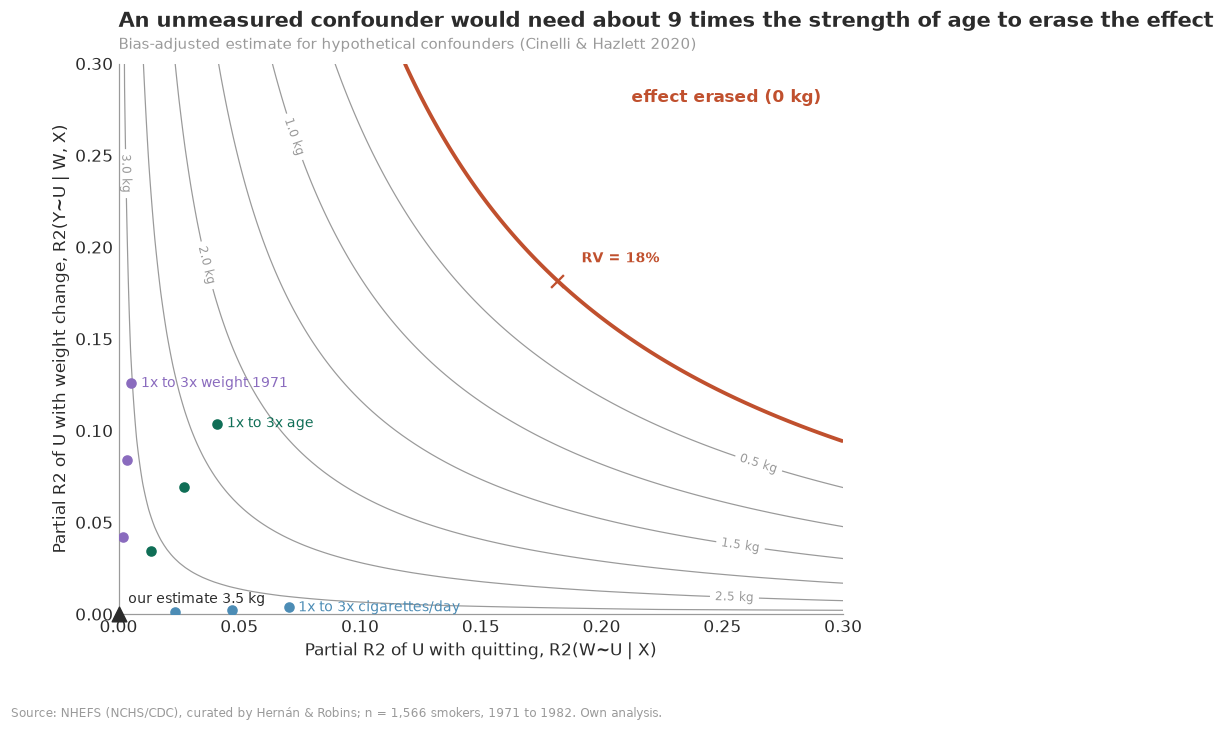

In [24]:
lim = max(0.3, 1.3 * rv)
grid = np.linspace(0, lim, 121)
RW, RY = np.meshgrid(grid, grid)
ADJ = est - se_lin * np.sqrt(dof) * np.sqrt(RY * RW / (1 - RW))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
cs = ax.contour(RW, RY, ADJ, levels=[0.5, 1, 1.5, 2, 2.5, 3], colors=GREY, linewidths=0.8)
ax.clabel(cs, fmt="%.1f kg", fontsize=8)
ax.contour(RW, RY, ADJ, levels=[0], colors=ACCENT_2, linewidths=2.5)
ax.text(lim * 0.97, lim * 0.93, "effect erased (0 kg)", color=ACCENT_2, ha="right", fontweight="bold")
ax.scatter([0], [0], marker="^", s=90, color=DARK, zorder=3, clip_on=False)
ax.text(0.004, 0.006, f"our estimate {est:.1f} kg", fontsize=9, color=DARK)
ax.scatter([rv], [rv], marker="x", s=70, color=ACCENT_2, zorder=3)
ax.text(rv + 0.01, rv + 0.01, f"RV = {rv:.0%}", color=ACCENT_2, fontsize=9, fontweight="bold")
for label, col in zip(BENCHMARKS, [ACCENT, "#4C8CB5", "#8A6BBE"]):
    pts = sens[sens.index.str.endswith(label)]
    ax.scatter(pts["R2(W~U|X)"], pts["R2(Y~U|W,X)"], color=col, s=35, zorder=3)
    last = pts.iloc[-1]
    ax.text(last["R2(W~U|X)"] + 0.004, last["R2(Y~U|W,X)"], f"1x to 3x {label}", color=col, fontsize=9, va="center")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Partial R2 of U with quitting, R2(W~U | X)")
ax.set_ylabel("Partial R2 of U with weight change, R2(Y~U | W, X)")
k_age = k_erase["age"]
k_age_txt = f"about {k_age:.0f} times" if np.isfinite(k_age) else "more than 100 times"
titles(ax, f"An unmeasured confounder would need {k_age_txt} the strength of age to erase the effect",
       "Bias-adjusted estimate for hypothetical confounders (Cinelli & Hazlett 2020)")
save(fig, "fig07c_sensitivity_contour")

### 7.5 Missing outcomes: inverse probability weighting for censoring

In [25]:
# [CONCEPT] IP weighting for censoring (Hernán & Robins, Ch. 12.6)
# [WHY]     Quitters were censored more often (Step 1.3). Weighting the uncensored by 1 / P(uncensored | W, X)
#           rebuilds the full cohort of 1,629, removing selection bias if censoring depends only on (W, X).
ps_all = smf.logit(f"{W_COL} ~ {PS_SPEC}", data=df_full).fit(disp=0).predict(df_full).to_numpy()  # all 1,629
w_all = df_full[W_COL].to_numpy()
p_quit_all = w_all.mean()
sw_treat = np.where(w_all == 1, p_quit_all / ps_all, (1 - p_quit_all) / (1 - ps_all))
p_cens_x = smf.logit(f"censored ~ {W_COL} + {PS_SPEC}", data=df_full).fit(disp=0).predict(df_full).to_numpy()
p_cens_w = smf.logit(f"censored ~ {W_COL}", data=df_full).fit(disp=0).predict(df_full).to_numpy()
sw_cens = (1 - p_cens_w) / (1 - p_cens_x)                        # stabilized censoring weights
observed = df_full["censored"].to_numpy() == 0

ipcw = smf.wls(f"{Y_COL} ~ {W_COL}", data=df_full[observed],
               weights=(sw_treat * sw_cens)[observed]).fit(cov_type="HC0")
ate_ipcw = ipcw.params[W_COL]
lo_ipcw, hi_ipcw = ipcw.conf_int().loc[W_COL]
CENS_OK = abs(ate_ipcw - ipw_est) < 0.5 * ladder.loc["IPW: treatment model", "se"]
print("IPW with censoring weights (1,629 people):", fmt_ci(ate_ipcw, lo_ipcw, hi_ipcw))
print("Complete-case IPW (1,566 people):          ", fmt_ci(ipw_est, *ladder.loc["IPW: treatment model", ["ci_low", "ci_high"]]))
print("✅ Censoring barely matters." if CENS_OK else "⚠️ Censoring changes the answer: report the weighted estimate.")
RESULTS.update({"ate_ipcw": ate_ipcw, "ate_ipcw_ci": (lo_ipcw, hi_ipcw)})

IPW with censoring weights (1,629 people): 3.50 kg (95% CI 2.47 to 4.53)
Complete-case IPW (1,566 people):           3.44 kg (95% CI 2.41 to 4.47)
✅ Censoring barely matters.


✅ **Checkpoint:** about 3.5 kg (2.5 to 4.5), as in Hernán & Robins Ch. 12.6.

### 7.6 Robustness scorecard

                            check                                              result  passed
            7.1 Placebo treatment        placebo mean +0.06 kg, real effect p = 0.048    True
          7.2 Random common cause                               largest shift 0.10 kg    True
7.3 Semi-synthetic (known effect)                        bias +0.09 kg, coverage 100%    True
       7.4 Unmeasured confounding RV = 18%; U needs about 9 times the strength of age    True
             7.5 Missing outcomes  3.50 kg with vs. 3.44 kg without censoring weights    True


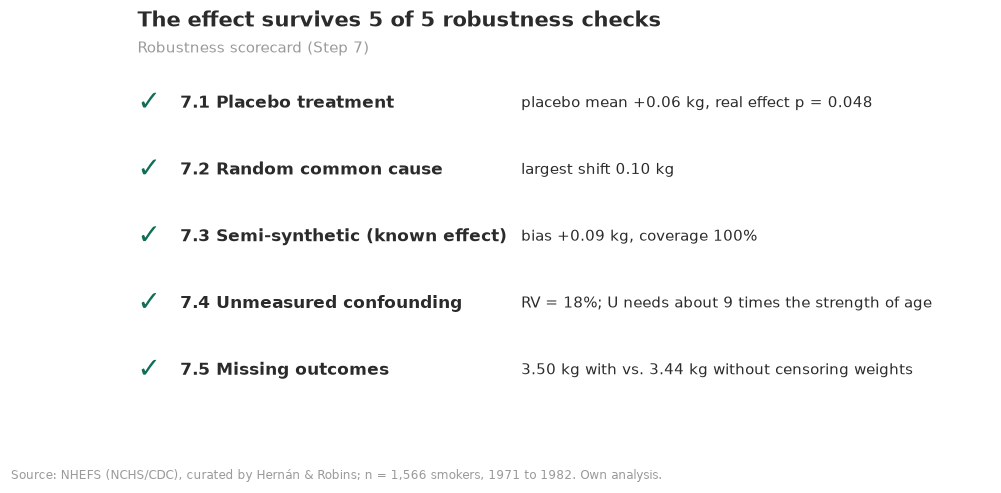

In [26]:
scorecard = pd.DataFrame([
    ["7.1 Placebo treatment", f"placebo mean {placebo_ates.mean():+.2f} kg, real effect p = {p_placebo:.3f}", PLACEBO_OK],
    ["7.2 Random common cause", f"largest shift {rcc_shift:.2f} kg", RCC_OK],
    ["7.3 Semi-synthetic (known effect)", f"bias {semi_summary.loc['no heterogeneity', 'bias']:+.2f} kg, "
                                          f"coverage {semi_summary.loc['no heterogeneity', 'coverage']:.0%}", SEMI_OK],
    ["7.4 Unmeasured confounding", f"RV = {rv:.0%}; U needs {k_age_txt} the strength of age", SENS_OK],
    ["7.5 Missing outcomes", f"{ate_ipcw:.2f} kg with vs. {ipw_est:.2f} kg without censoring weights", CENS_OK],
], columns=["check", "result", "passed"])
n_pass = int(scorecard["passed"].sum())
RESULTS["robustness_passed"] = f"{n_pass}/{len(scorecard)}"
print(scorecard.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 0.62 * len(scorecard) + 1.0))
ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(-0.6, len(scorecard) - 0.4)
for i, row in enumerate(scorecard.itertuples()):
    yv = len(scorecard) - 1 - i
    mark, col = ("✓", ACCENT) if row.passed else ("✗", ACCENT_2)
    ax.text(0.0, yv, mark, color=col, fontsize=18, fontweight="bold", va="center")
    ax.text(0.05, yv, row.check, fontsize=11, fontweight="bold", color=DARK, va="center")
    ax.text(0.45, yv, row.result, fontsize=10, color=DARK, va="center")
titles(ax, f"The effect survives {n_pass} of {len(scorecard)} robustness checks", "Robustness scorecard (Step 7)")
save(fig, "fig07d_robustness_scorecard")

> 📝 **Document (Step 7)**
> - Each check: idea, expectation, result (the scorecard), and what a failure would have meant
> - Placebo distribution and permutation p-value (note the minimum attainable p with 20 refits)
> - Semi-synthetic design ($f_0$, noise level, two scenarios) and the power statement it supports
> - Sensitivity: RV, RV$_\alpha$, benchmark table, "U would need about k times the strength of age"
> - Censoring-weighted estimate vs. complete-case estimate
>
> 🎤 **Slide candidates:** `fig07d_robustness_scorecard.png` (compact, works for any audience) and `fig07c_sensitivity_contour.png` (technical audience or Q&A backup).

---
## Step 8. Interpretation

🔗 Causal Forests slides, take-home message: *BLP gives trends, the calibration test asks whether it is real, partial dependence shows shape.* Everything in this step is conditional on Step 6: if the calibration test did not confirm heterogeneity, these are exploratory descriptions, not findings.

### 8.1 Best linear projection

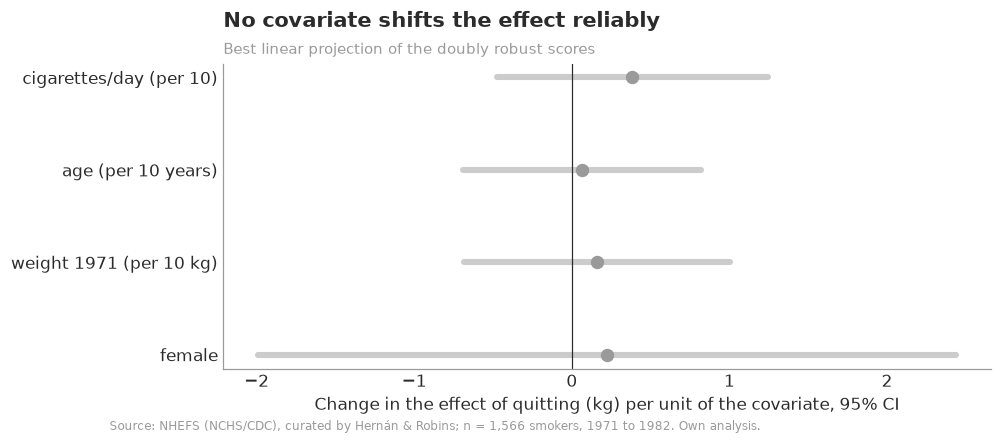

,coef,se,p,ci_low,ci_high
const,3.384,0.471,0.000,2.462,4.306
cigarettes/day (per 10),0.385,0.438,0.380,-0.473,1.242
age (per 10 years),0.064,0.386,0.868,-0.693,0.821
weight 1971 (per 10 kg),0.157,0.430,0.715,-0.686,1.001
female,0.223,1.129,0.843,-1.990,2.436


In [27]:
# [CONCEPT] Best linear projection: OLS of the doubly robust scores on chosen covariates A
# 📐 Gamma_i = beta_0 + A_i' beta + eps_i  (HC3 standard errors)
# [WHY]     A transparent summary of the black box: how does the effect TREND with A?
#           Read slopes as trends, not causal effects of A (A itself is not randomized).
# [TIP]     Centring A makes the intercept the ATE for an average smoker.
A = pd.DataFrame({
    "cigarettes/day (per 10)": (df["smokeintensity"] - df["smokeintensity"].mean()) / 10,
    "age (per 10 years)": (df["age"] - df["age"].mean()) / 10,
    "weight 1971 (per 10 kg)": (df["wt71"] - df["wt71"].mean()) / 10,
    "female": df["sex"] - df["sex"].mean(),
})
blp = sm.OLS(Gamma, sm.add_constant(A)).fit(cov_type="HC3")
blp_tab = pd.DataFrame({"coef": blp.params, "se": blp.bse, "p": blp.pvalues})
blp_tab["ci_low"], blp_tab["ci_high"] = blp_tab["coef"] - Z_CRIT * blp_tab["se"], blp_tab["coef"] + Z_CRIT * blp_tab["se"]
RESULTS.update({f"blp_{k}": v for k, v in blp_tab["coef"].items()})
RESULTS.update({f"blp_p_{k}": v for k, v in blp_tab["p"].items()})

slopes = blp_tab.drop(index="const")
fig, ax = plt.subplots(figsize=(9, 3.6))
yy = np.arange(len(slopes))[::-1]
for yi, (name, row) in zip(yy, slopes.iterrows()):
    col = ACCENT if row["p"] < ALPHA else GREY
    ax.plot([row["ci_low"], row["ci_high"]], [yi, yi], color=col, lw=4, alpha=0.5, solid_capstyle="round")
    ax.scatter(row["coef"], yi, color=col, s=60, zorder=3)
ax.axvline(0, color=DARK, lw=0.8)
ax.set_yticks(yy, labels=slopes.index)
ax.set_xlabel("Change in the effect of quitting (kg) per unit of the covariate, 95% CI")
titles(ax, "No covariate shifts the effect reliably" if (slopes["p"] >= ALPHA).all()
       else "Some covariates shift the effect",
       "Best linear projection of the doubly robust scores")
save(fig, "fig08a_blp")
blp_tab.round(3)

### 8.2 Partial dependence: the shape of the effect
Vary one covariate over a grid, hold the others at their median, predict $\hat\tau(x) \pm 1.96\,\widehat{se}(x)$ (lecture definition). The dark points are **model-free** checks: the average doubly robust score within bins of the real data.

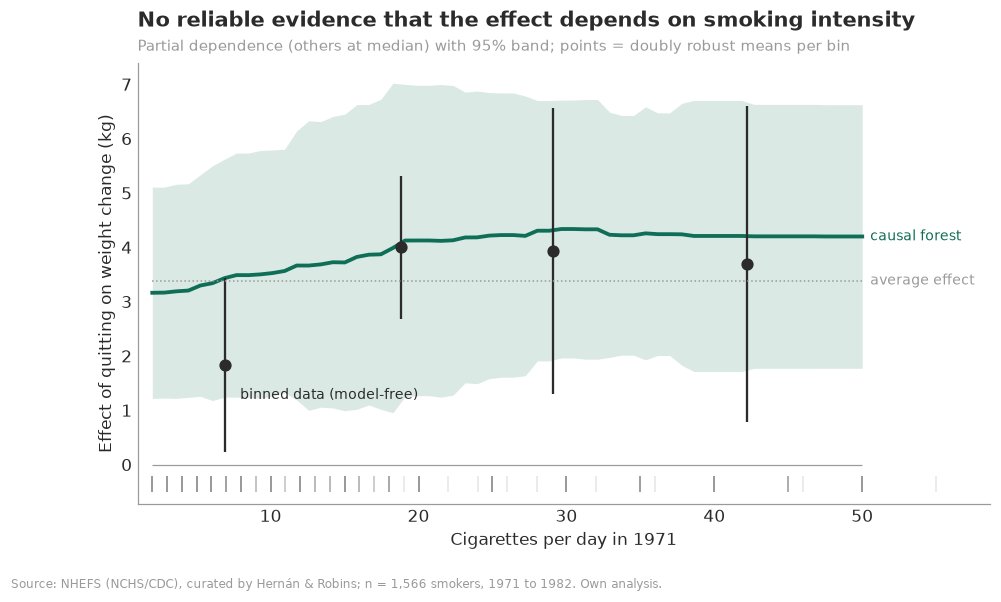

              x   est    se    n
bin                             
(0, 10]    6.91  1.83  0.82  406
(10, 20]  18.84  4.00  0.67  718
(20, 30]  29.07  3.93  1.35  216
(30, 80]  42.19  3.70  1.48  226


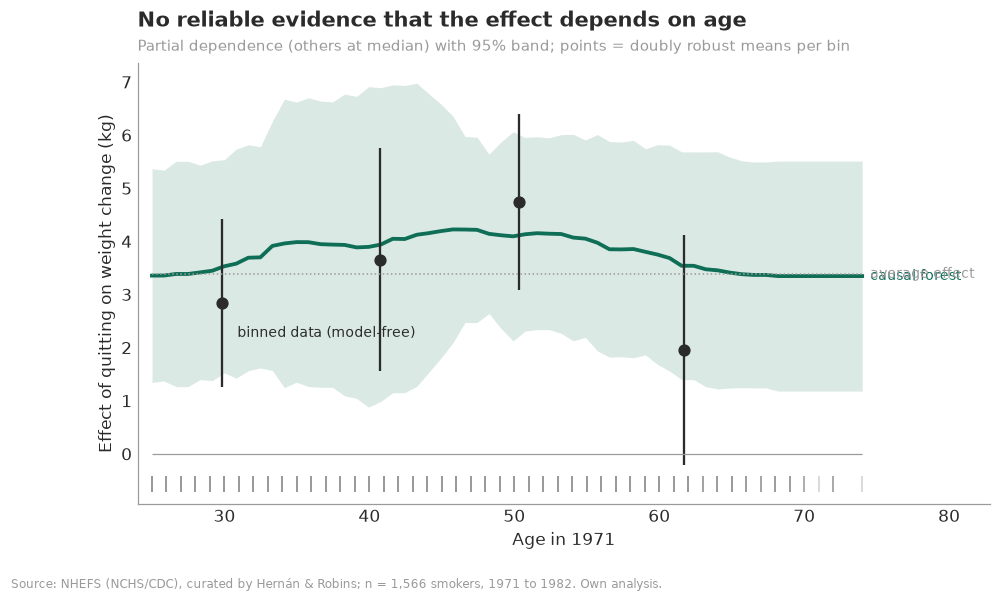

              x   est    se    n
bin                             
(24, 35]  29.84  2.83  0.81  490
(35, 45]  40.72  3.66  1.07  374
(45, 55]  50.29  4.74  0.85  420
(55, 75]  61.70  1.96  1.10  282


In [28]:
# ⚠️ Lecture caveats: (1) the "median person" may sit where data are sparse (wide bands are the honest
#    price); (2) varying one covariate with the rest frozen need not describe any real subgroup.
X_median = np.median(X, axis=0)


def partial_dependence(col, grid):
    X_grid = np.tile(X_median, (len(grid), 1))
    X_grid[:, X_COLS.index(col)] = grid
    pred, var = cf.predict_and_var(X_grid)
    return pred.ravel(), np.sqrt(var.ravel())


def binned_scores(col, edges):
    tab = pd.DataFrame({"bin": pd.cut(df[col], edges), "G": Gamma, "x": df[col]})
    return tab.groupby("bin", observed=True).agg(
        x=("x", "mean"), est=("G", "mean"), se=("G", lambda s: s.std(ddof=1) / np.sqrt(len(s))), n=("G", "size"))


def plot_pd(col, grid, edges, xlabel, blp_row, fname, unit_word):
    pd_est, pd_se = partial_dependence(col, grid)
    bins_ = binned_scores(col, edges)
    fig, ax = plt.subplots(figsize=(10, 5.2))
    ax.fill_between(grid, pd_est - Z_CRIT * pd_se, pd_est + Z_CRIT * pd_se, color=ACCENT, alpha=0.15, lw=0)
    ax.plot(grid, pd_est, color=ACCENT, lw=2.5)
    ax.errorbar(bins_["x"], bins_["est"], yerr=Z_CRIT * bins_["se"], fmt="o", color=DARK, ms=7, lw=1.5, capsize=0)
    ax.hlines(ate_cf, grid[0], grid[-1], color=GREY, ls=":", lw=1)
    ax.hlines(0, grid[0], grid[-1], color=GREY, lw=0.8)
    ax.text(grid[-1], pd_est[-1], "  causal forest", color=ACCENT, va="center", fontsize=9)
    ax.text(grid[-1], ate_cf, "  average effect", color=GREY, va="center", fontsize=9)
    first = bins_.iloc[0]
    ax.annotate("binned data (model-free)", (first["x"], first["est"]), xytext=(10, -22),
                textcoords="offset points", color=DARK, fontsize=9)
    ymin = ax.get_ylim()[0]
    ax.plot(df[col], np.full(n, ymin), "|", color=GREY, alpha=0.25, ms=10)   # rug: where the data are
    ax.set_xlim(grid[0] - 1, grid[-1] + (grid[-1] - grid[0]) * 0.18)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Effect of quitting on weight change (kg)")
    sig = blp_tab.loc[blp_row, "p"] < ALPHA
    direction = "grows" if blp_tab.loc[blp_row, "coef"] > 0 else "shrinks"
    titles(ax, f"The effect {direction} with {unit_word}" if sig
           else f"No reliable evidence that the effect depends on {unit_word}",
           "Partial dependence (others at median) with 95% band; points = doubly robust means per bin")
    save(fig, fname)
    return bins_


lo_c, hi_c = np.percentile(df["smokeintensity"], [2, 98])
bins_cig = plot_pd("smokeintensity", np.linspace(lo_c, hi_c, 60), [0, 10, 20, 30, 80],
                   "Cigarettes per day in 1971", "cigarettes/day (per 10)", "fig08b_pd_cigarettes", "smoking intensity")
print(bins_cig.round(2))
bins_age = plot_pd("age", np.linspace(df["age"].min(), df["age"].max(), 60), [24, 35, 45, 55, 75],
                   "Age in 1971", "age (per 10 years)", "fig08c_pd_age", "age")
print(bins_age.round(2))

### 8.3 Effects for illustrative profiles
Useful for storytelling, but word it carefully: $\hat\tau(x)$ is the average effect **for people like this profile**, not the personal counterfactual of one individual.

                                                     tau  ci_low  ci_high
Light smoker: woman, 30, 5 cig/day, 10 years, 6...  2.56    1.13     3.98
Typical smoker: median on every covariate           4.12    1.27     6.98
Heavy smoker: man, 50, 40 cig/day, 30 years, 85 kg  2.62    1.18     4.07


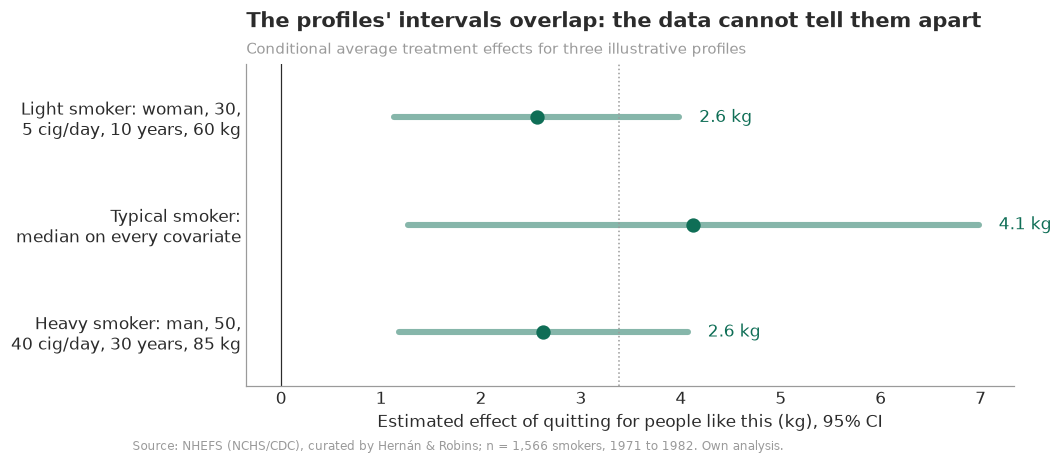

In [29]:
profiles = {
    "Light smoker: woman, 30,\n5 cig/day, 10 years, 60 kg": {"age": 30, "sex": 1, "smokeintensity": 5, "smokeyrs": 10, "wt71": 60},
    "Typical smoker:\nmedian on every covariate": {},
    "Heavy smoker: man, 50,\n40 cig/day, 30 years, 85 kg": {"age": 50, "sex": 0, "smokeintensity": 40, "smokeyrs": 30, "wt71": 85},
}
base_profile = dict(zip(X_COLS, X_median))
X_prof = np.array([[{**base_profile, **p}[c] for c in X_COLS] for p in profiles.values()], dtype=float)
tau_prof = cf.predict(X_prof).ravel()
lo_prof, hi_prof = (a.ravel() for a in cf.predict_interval(X_prof, alpha=ALPHA))
prof_tab = pd.DataFrame({"tau": tau_prof, "ci_low": lo_prof, "ci_high": hi_prof},
                        index=[k.replace("\n", " ") for k in profiles])
print(prof_tab.round(2))

fig, ax = plt.subplots(figsize=(9, 3.8))
yy = np.arange(len(profiles))[::-1]
for yi, t_, l_, h_ in zip(yy, tau_prof, lo_prof, hi_prof):
    ax.plot([l_, h_], [yi, yi], color=ACCENT, lw=4, alpha=0.5, solid_capstyle="round")
    ax.scatter(t_, yi, color=ACCENT, s=70, zorder=3)
    ax.text(h_ + 0.2, yi, f"{t_:.1f} kg", va="center", color=ACCENT)
ax.axvline(ate_cf, color=GREY, ls=":", lw=1)
ax.axvline(0, color=DARK, lw=0.8)
ax.set_yticks(yy, labels=list(profiles))
ax.set_ylim(-0.5, len(profiles) - 0.5)
ax.set_xlabel("Estimated effect of quitting for people like this (kg), 95% CI")
overlap = lo_prof.max() < hi_prof.min()
titles(ax, "The profiles' intervals overlap: the data cannot tell them apart" if overlap
       else "The profiles differ in their expected weight gain",
       "Conditional average treatment effects for three illustrative profiles")
save(fig, "fig08d_profiles")

### 8.4 Executive summary (Minto skeleton filled with your numbers) and export

In [30]:
lo_cf, hi_cf = RESULTS["ate_aipw_cf_ci"]
adjusted = ladder["estimate"].iloc[1:]
rate_sig = any(rr["autoc"] - Z_CRIT * rr["se"] > 0 for rr in rate_res.values())
blp_sig = bool((slopes["p"] < ALPHA).any())
evidence = (f"calibration beta = {calib['beta']:.2f}, one-sided p = {calib['p_beta_gt_0']:.2f}; "
            f"RATE {'significant' if rate_sig else 'not significant'}; "
            f"best linear projection {'with significant slopes' if blp_sig else 'not significant'}")
het_line = (f"The effect differs between smokers ({evidence})." if HETEROGENEITY_DETECTED else
            f"We find no reliable evidence that it differs between smokers ({evidence}).")
summary = f"""
MAIN IDEA (treatment + treatment effect)
  Quitting smoking causes about {ate_cf:.1f} kg additional weight gain over 11 years (95% CI {lo_cf:.1f} to {hi_cf:.1f}).
  {het_line}

KEY LINE 1: the raw number is misleading
  Naive difference {naive:.1f} kg. Quitters were older and smoked less (largest ASMD {RESULTS['asmd_max_unadjusted']:.2f});
  after weighting every ASMD is below {RESULTS['asmd_max_weighted']:.2f}.

KEY LINE 2: the adjusted number is robust
  {len(adjusted)} adjusted estimators between {adjusted.min():.1f} and {adjusted.max():.1f} kg; IPW reproduces Hernán & Robins ({REF_HR['estimate']} kg).
  {n_pass} of {len(scorecard)} robustness checks passed. An unmeasured confounder would need {rv:.0%} partial R2 with both
  quitting and weight change ({k_age_txt} the strength of age) to erase the effect.

KEY LINE 3: what it means (adapt to your audience)
  {'Target weight support at the groups identified in Step 8.' if HETEROGENEITY_DETECTED else
   'Offer weight support to all quitters; the data give no basis for targeting a subgroup.'}
  About {ate_cf / 11:.1f} kg per year, small compared with the health benefits of quitting.
"""
print(summary)

def to_builtin(v):
    if isinstance(v, (np.floating, np.integer)):
        return v.item()
    if isinstance(v, np.bool_):
        return bool(v)
    if isinstance(v, (tuple, list)):
        return [to_builtin(x) for x in v]
    return v

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
with open(RESULTS_DIR / "results_summary.json", "w") as fh:
    json.dump({k: to_builtin(v) for k, v in RESULTS.items()}, fh, indent=2)
ladder.round(3).to_csv(RESULTS_DIR / "ate_ladder.csv")
sens.round(4).to_csv(RESULTS_DIR / "sensitivity.csv")
scorecard.to_csv(RESULTS_DIR / "robustness_scorecard.csv", index=False)
blp_tab.round(4).to_csv(RESULTS_DIR / "best_linear_projection.csv")
(RESULTS_DIR / "executive_summary.txt").write_text(summary, encoding="utf-8")
print("Exported to", RESULTS_DIR.resolve(), "and figures to", FIG_DIR.resolve())


MAIN IDEA (treatment + treatment effect)
  Quitting smoking causes about 3.4 kg additional weight gain over 11 years (95% CI 2.5 to 4.3).
  We find no reliable evidence that it differs between smokers (calibration beta = 0.54, one-sided p = 0.14; RATE not significant; best linear projection not significant).

KEY LINE 1: the raw number is misleading
  Naive difference 2.5 kg. Quitters were older and smoked less (largest ASMD 0.20);
  after weighting every ASMD is below 0.03.

KEY LINE 2: the adjusted number is robust
  4 adjusted estimators between 3.3 and 3.5 kg; IPW reproduces Hernán & Robins (3.4 kg).
  5 of 5 robustness checks passed. An unmeasured confounder would need 18% partial R2 with both
  quitting and weight change (about 9 times the strength of age) to erase the effect.

KEY LINE 3: what it means (adapt to your audience)
  Offer weight support to all quitters; the data give no basis for targeting a subgroup.
  About 0.3 kg per year, small compared with the health benefits

---
## Wrap-up for the background document and the presentation

**Minto pyramid** (answer first). The *main idea* must follow the "treatment + treatment effect" structure; fill it with the printed summary above.
- **Situation:** Quitting is the most effective step a smoker can take for their health.
- **Complication:** Many smokers fear weight gain, and raw data understate it because quitters differ from continuing smokers.
- **Question:** How much weight does quitting really cause, and for whom?
- **Answer / main idea:** see `MAIN IDEA` above.
- **Key lines:** raw number misleading (Step 4), adjusted number robust (Steps 5 and 7), implication for your audience (Step 8).

**Limitations** (the lecture's "limitations before conclusions")
1. Unconfoundedness is untestable; bounded by the sensitivity analysis (RV, benchmark against age).
2. "Quitting" is a compound treatment (timing and relapse unknown): consistency is approximate.
3. Complete-case analysis; censoring was informative, but IP weighting for censoring barely changes the result.
4. Smoking is self-reported; measurement error in W and X.
5. US cohort 1971 to 1982: transport to today (other products, diets, populations) is an assumption.
6. Limited power for heterogeneity (quantified in Step 7.3): a null CATE result means "not detectable with n = 1,566", not "identical for everyone".
7. Total effect: includes mediated pathways such as appetite and metabolism.
8. ASMD uses the lecture definition (differs by a factor of √2 from common software).

**Presentation plan (8 minutes, figures in `figures/`)**

| Slide | Message | Figure |
|---|---|---|
| 1 | Main idea first (one number, one sentence) | none, or the ladder's final estimate |
| 2 | Why raw data mislead: the groups differ | `fig04b_love_plot` |
| 3 | How we identify the effect | `fig02_dag` |
| 4 | The result and its validation | `fig05b_ate_ladder` |
| 5 | For whom? | `fig08b_pd_cigarettes` (or `fig06b_heterogeneity_check` for a technical audience) |
| 6 | How sure are we? | `fig07d_robustness_scorecard` |
| 7 | Recommendation and transition | none |

Backup for Q&A: `fig04a_overlap`, `fig06a_calibration`, `fig06c_rate_toc`, `fig07a_placebo`, `fig07b_semisynthetic`, `fig07c_sensitivity_contour`, `fig08a_blp`, `fig08d_profiles`.